# # 20. Batch PPO Trading - SRL Evaluation
En este notebook entrenamos y evaluamos agentes de Reinforcement Learning (DQN) 
utilizando las representaciones de estado extraídas mediante AE, CPC y Transformer.

In [1]:
import pandas as pd
import numpy as np
import os
import random
import torch
import json
import warnings
warnings.filterwarnings("ignore")

import gymnasium as gym
from stable_baselines3 import PPO,DQN
from stable_baselines3.common.vec_env import DummyVecEnv


# Configuración de rutas
import sys
sys.path.append('../')
from src.trading_env_improved  import SRLTradingEnv  # Importamos tu entorno modular
from sklearn.preprocessing import MinMaxScaler
from src.SRLTradingEnv_v2 import SRLTradingEnv_v2

# ## 1. Configuración Global y Reproducibilidad

In [2]:
N_SEEDS = 5
# [42,123,456,789,1011]
SEEDS = [42, 123, 456, 789, 1011]
TIMEFRAME = '1h'
#['raw','baseline','temporal-ae', 'cpc', 'transformer', 'combinado'] 
MODELS_TO_TEST =['raw','baseline','temporal-ae', 'cpc', 'transformer', 'combinado'] # Los 3 que hemos creado + el baseline
# Fecha para separar Train y Validación (ajusta según tu dataset)
FROM_SAFE = '2021-12-31_00-00-00'
UNTIL_SAFE = '2025-07-31_00-00-00'

#TRAIN_END_DATE = '2024-12-31' #para bitcoin
TRAIN_END_DATE = '2025-04-10' # para spy

foldername = "SP500"
#foldername = "BTC"
data_name = "SPY"
#data_name = "BTCUSDT"

#val_size = 4698 # para bitcoin
val_size = 535 # para spy



INITIAL_BALANCE = 1000
FEE = 0.001 # 0.1% comisión (Binance Standard)

# Crear carpetas de salida
os.makedirs(f'../RL_outputs/{foldername}/results', exist_ok=True)
os.makedirs(f'../RL_outputs/{foldername}/models', exist_ok=True)

# ## 2. Funciones de Soporte

In [3]:
def load_data_all_types(model_type, tf):
    # 1. Cargamos precios base
    price_path = f'../data/{foldername}/01-output-{data_name}_{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}-log-return.csv'
    df_prices_full = pd.read_csv(price_path, index_col='date', parse_dates=True)
    
    if model_type == 'baseline':
        path = f'../data/{foldername}/02-baseline-{data_name}_{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}-technical-indicators.csv'
        df_feat = pd.read_csv(path, index_col='date', parse_dates=True)
        # IMPORTANTE: Los indicadores técnicos suelen estar ya "lagged" (basados en el pasado),
        # pero por seguridad, si ves que el baseline también vuela, añade aquí un .shift(1)
    
    elif model_type == 'combinado':
        paths = {
            'ae': f'../data/{foldername}/02-srl-temporal-ae-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv',
            'cpc': f'../data/{foldername}/02-srl-cpc-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv',
            'trans': f'../data/{foldername}/02-srl-transformer-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv'
        }
        df_ae = pd.read_csv(paths['ae'], index_col='date', parse_dates=True)
        df_cpc = pd.read_csv(paths['cpc'], index_col='date', parse_dates=True)
        df_trans = pd.read_csv(paths['trans'], index_col='date', parse_dates=True)
        df_feat = df_ae.join(df_cpc, how='inner').join(df_trans, how='inner')
        # Los modelos SRL ya son representaciones del PASADO, no necesitan shift.
    
    elif model_type == 'raw':
        # USAMOS EL RETORNO PERO DESPLAZADO
        df_feat = df_prices_full[['close']].copy().rename(columns={'close': 'raw_ret'})
        df_feat = df_feat.shift(1) # <--- LA CLAVE: El agente ve el retorno de la hora ANTERIOR
        
    else:
        emb_path = f'../data/{foldername}/02-srl-{model_type}-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv'
        df_feat = pd.read_csv(emb_path, index_col='date', parse_dates=True)
    
    # --- Limpieza y Sincronización ---
    cols_to_drop = ['open', 'high', 'low', 'close', 'volume', 'tradecount']
    df_feat = df_feat.drop(columns=[c for c in cols_to_drop if c in df_feat.columns], errors='ignore')
    
    combined = df_feat.join(df_prices_full[['close']], how='inner').dropna()
    
    # Blindaje contra infinitos/NaNs
    combined = combined.replace([np.inf, -np.inf], np.nan).ffill().bfill().dropna()
    
    prices = combined['close']
    features = combined.drop(columns=['close'])
    
    return features, prices



def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [4]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo detectado: {device}")
if torch.cuda.is_available():
    print(f"Ferrari detectado: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ ATENCIÓN: Sigues en el bus (CPU).")

Dispositivo detectado: cuda
Ferrari detectado: NVIDIA GeForce RTX 4060 Laptop GPU


# ## 3. Bucle Principal de Entrenamiento y Comparativa

In [5]:
batch_results = []

for model_name in MODELS_TO_TEST:
    print(f"\n" + "="*50)
    print(f" EVALUANDO MODELO: {model_name.upper()} ")
    print("="*50)
    
    try:
        df_feat, df_prices = load_data_all_types(model_name, TIMEFRAME)
    except FileNotFoundError as e:
        print(f"Error: No se encontró el archivo para {model_name}. Saltando...")
        continue

    # --- CAMBIO 1: ESCALADO UNIVERSAL (FUNDAMENTAL) ---
    # Escalamos TODOS los modelos, no solo el baseline. 
    # PPO necesita que los embeddings (AE, CPC, Trans) estén en el mismo rango.
    scaler = MinMaxScaler()
    train_mask = df_feat.index <= TRAIN_END_DATE
    
    # Aseguramos que no haya NaNs antes de escalar
    df_feat = df_feat.ffill().bfill().fillna(0) 
    
    # Ajustamos el scaler solo con entrenamiento y transformamos ambos
    df_feat.loc[train_mask] = scaler.fit_transform(df_feat.loc[train_mask])
    df_feat.loc[~train_mask] = scaler.transform(df_feat.loc[~train_mask])
    
    # Split temporal
    df_feat_train = df_feat[df_feat.index <= TRAIN_END_DATE]
    df_prices_train = df_prices[df_prices.index <= TRAIN_END_DATE]
    
    df_feat_val = df_feat[df_feat.index > TRAIN_END_DATE]
    df_prices_val = df_prices[df_prices.index > TRAIN_END_DATE]
    
    print(f"Dataset: {len(df_feat_train)} pasos entrenamiento | {len(df_feat_val)} pasos validación")

    for seed in SEEDS:
        print(f"> Semilla {seed}...")
        set_seed(seed)
        
        # 1. Entorno de ENTRENAMIENTO
        train_env = DummyVecEnv([lambda: SRLTradingEnv_v2(
            df_feat_train, 
            df_prices_train, 
            initial_balance=INITIAL_BALANCE, 
            fee=FEE
        )])
        
        # 2. Agente PPO con PARARRAYOS (max_grad_norm)
        agent = PPO(
            "MlpPolicy",
            train_env,
            learning_rate=1e-4,    # Sube la velocidad de aprendizaje
            n_steps=2048,
            batch_size=64,
            gamma=0.99,
            max_grad_norm=0.5,     # Relajamos un poco el pararrayos (era 0.3)
            clip_range=0.2,        # --- CAMBIO CLAVE: Permite cambios más audaces ---
            ent_coef=0.01,         # --- EL DESPERTADOR: Obliga a explorar acciones ---
            verbose=0,
            seed=seed
        )
        
        # 3. Entrenamiento con red de seguridad
        try:
            total_steps = len(df_feat_train) * 20
            agent.learn(total_timesteps=total_steps)
        except ValueError as e:
            print(f"❌ Error fatal en semilla {seed}: {e}. Saltando...")
            continue
        
        # 4. Entorno de VALIDACIÓN
        val_env = SRLTradingEnv_v2(
            df_feat_val, 
            df_prices_val, 
            initial_balance=INITIAL_BALANCE, 
            fee=FEE
        )
        
        obs, _ = val_env.reset()
        done = False
        history = []

        while not done:
            action, _ = agent.predict(obs, deterministic=True)
            obs, reward, done, _, info = val_env.step(action)
            history.append(info['net_worth'])
        
        final_nw = history[-1]
        total_return = (final_nw - INITIAL_BALANCE) / INITIAL_BALANCE
        print(f"   [Semilla {seed}] Retorno Final: {total_return*100:.2f}%")
        
        batch_results.append({
            'srl_model': model_name,
            'seed': seed,
            'final_net_worth': final_nw,
            'total_return': total_return,
            'equity_curve': history
        })
        
        agent.save(f"../RL_outputs/{foldername}/models/ppo_{model_name}_seed_{seed}")
        print(f"   Modelo guardado: ../RL_outputs/{foldername}/models/ppo_{model_name}_seed_{seed}")


 EVALUANDO MODELO: RAW 
Dataset: 26302 pasos entrenamiento | 4698 pasos validación
> Semilla 42...
   [Semilla 42] Retorno Final: 20.97%
   Modelo guardado: ../RL_outputs/BTC/models/ppo_raw_seed_42
> Semilla 123...
   [Semilla 123] Retorno Final: 25.67%
   Modelo guardado: ../RL_outputs/BTC/models/ppo_raw_seed_123
> Semilla 456...
   [Semilla 456] Retorno Final: 19.90%
   Modelo guardado: ../RL_outputs/BTC/models/ppo_raw_seed_456
> Semilla 789...
   [Semilla 789] Retorno Final: 23.04%
   Modelo guardado: ../RL_outputs/BTC/models/ppo_raw_seed_789
> Semilla 1011...
   [Semilla 1011] Retorno Final: 20.04%
   Modelo guardado: ../RL_outputs/BTC/models/ppo_raw_seed_1011

 EVALUANDO MODELO: BASELINE 
Dataset: 26278 pasos entrenamiento | 4698 pasos validación
> Semilla 42...
   [Semilla 42] Retorno Final: 0.00%
   Modelo guardado: ../RL_outputs/BTC/models/ppo_baseline_seed_42
> Semilla 123...
   [Semilla 123] Retorno Final: 0.00%
   Modelo guardado: ../RL_outputs/BTC/models/ppo_baseline_seed_

# ## 4. Resumen de Resultados y Comparativa

In [6]:
df_results = pd.DataFrame(batch_results)
summary = df_results.groupby('srl_model')['total_return'].agg(['mean', 'std', 'max']).reset_index()

print("\n" + "#"*50)
print(" COMPARATIVA FINAL DE RENDIMIENTO ")
print("#"*50)
print(summary)

df_results.to_csv(f'../RL_outputs/{foldername}/results/PPO_SRL_Comparison_Summary.csv', index=False)


##################################################
 COMPARATIVA FINAL DE RENDIMIENTO 
##################################################
     srl_model      mean       std       max
0     baseline -0.015929  0.126507  0.136405
1    combinado  0.116385  0.337922  0.626437
2          cpc  0.823849  0.411992  1.344259
3          raw  0.219281  0.024405  0.256726
4  temporal-ae  0.054460  0.098382  0.216658
5  transformer  0.052806  0.118077  0.264028


In [7]:
# 1. Calcular el retorno del Bitcoin (Buy & Hold) en el periodo de validación
price_start = df_prices_val.iloc[0]
price_end = df_prices_val.iloc[-1]
bh_return = (price_end - price_start) / price_start

# 2. Agrupar resultados de la IA (Media de todas las semillas)
ia_summary = df_results.groupby('srl_model')['total_return'].mean().reset_index()
ia_summary.columns = ['Modelo', 'Retorno_IA']

# 3. Calcular el "Alpha" (Exceso de retorno sobre el mercado)
ia_summary['Buy_Hold_BTC'] = bh_return
ia_summary['Alpha'] = ia_summary['Retorno_IA'] - ia_summary['Buy_Hold_BTC']

# 4. Formatear para lectura fácil
ia_summary['Retorno_IA'] = ia_summary['Retorno_IA'].map(lambda x: f"{x*100:.2f}%")
ia_summary['Buy_Hold_BTC'] = ia_summary['Buy_Hold_BTC'].map(lambda x: f"{x*100:.2f}%")
ia_summary['Alpha'] = ia_summary['Alpha'].map(lambda x: f"{x*100:.2f}%")

print("="*60)
print(f" BENCHMARK: {TRAIN_END_DATE} hasta Final ")
print("="*60)
print(f"Precio inicial BTC: ${price_start:,.2f}")
print(f"Precio final BTC:   ${price_end:,.2f}")
print(f"RETORNO MERCADO:    {bh_return*100:.2f}%")
print("-"*60)
print(ia_summary)
print("="*60)

# Verificación de "Outperformance"
best_model = df_results.groupby('srl_model')['total_return'].mean().idxmax()
best_return = df_results.groupby('srl_model')['total_return'].mean().max()

if best_return > bh_return:
    print(f"🚀 ¡ÉXITO! El modelo {best_model.upper()} ha batido al mercado.")
else:
    print(f"⚖️ El mercado ha sido más fuerte. El modelo {best_model.upper()} ha sido más conservador.")

 BENCHMARK: 2024-12-31 hasta Final 
Precio inicial BTC: $92,435.57
Precio final BTC:   $115,764.08
RETORNO MERCADO:    25.24%
------------------------------------------------------------
        Modelo Retorno_IA Buy_Hold_BTC    Alpha
0     baseline     -1.59%       25.24%  -26.83%
1    combinado     11.64%       25.24%  -13.60%
2          cpc     82.38%       25.24%   57.15%
3          raw     21.93%       25.24%   -3.31%
4  temporal-ae      5.45%       25.24%  -19.79%
5  transformer      5.28%       25.24%  -19.96%
🚀 ¡ÉXITO! El modelo CPC ha batido al mercado.



 📊 REPORTE VISUAL PPO: RAW | SEED: 42
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   27
📉 Entradas Short:  0
✖️  Cierres (Out):   26
🔄 Operaciones totales: 53
----------------------------------
💰 Patrimonio Final: $1209.75
📊 Retorno IA:       20.97%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -4.53%


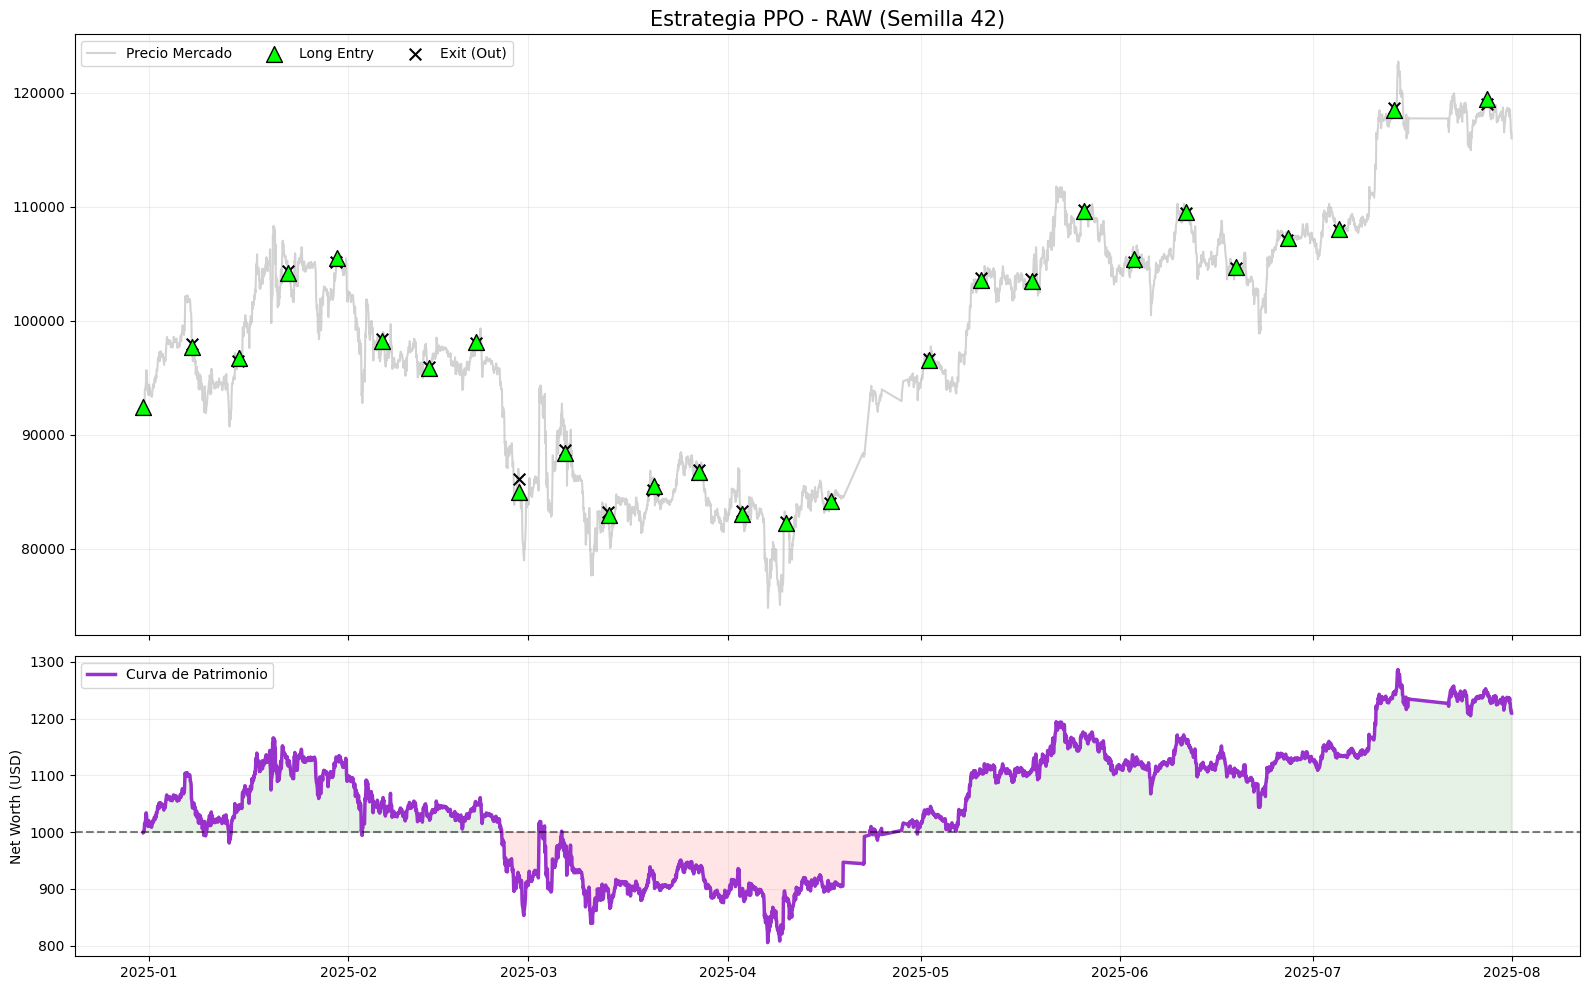


 📊 REPORTE VISUAL PPO: BASELINE | SEED: 42
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   0
📉 Entradas Short:  0
✖️  Cierres (Out):   0
🔄 Operaciones totales: 0
----------------------------------
💰 Patrimonio Final: $1000.00
📊 Retorno IA:       0.00%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -25.50%


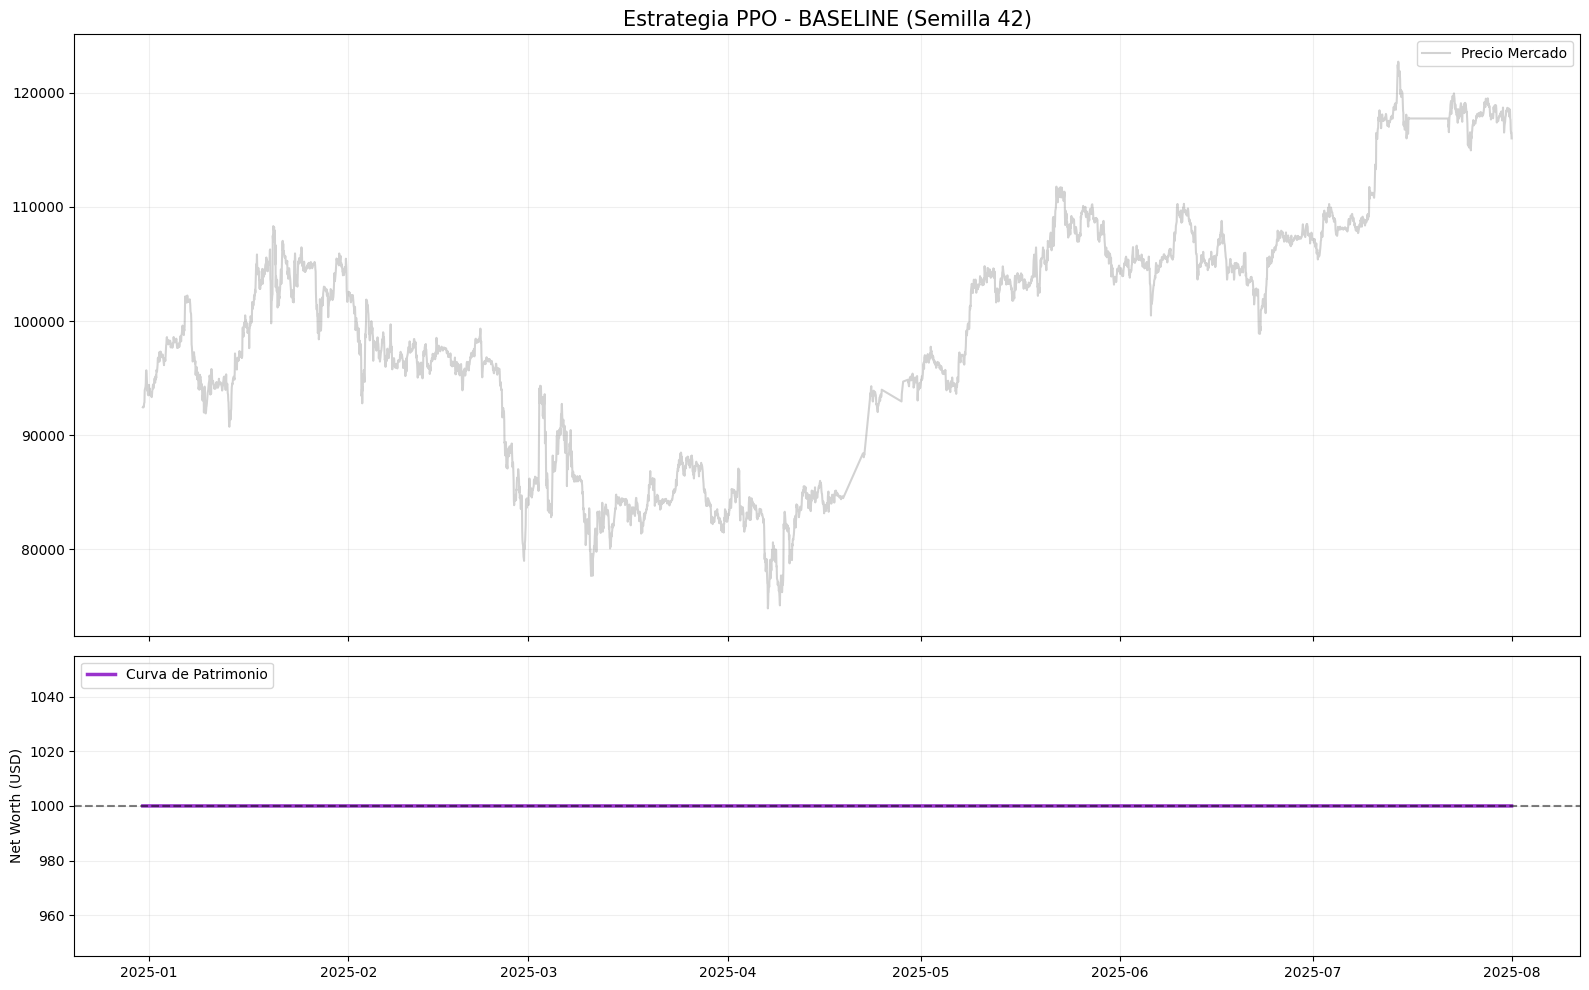


 📊 REPORTE VISUAL PPO: BASELINE | SEED: 123
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   0
📉 Entradas Short:  0
✖️  Cierres (Out):   0
🔄 Operaciones totales: 0
----------------------------------
💰 Patrimonio Final: $1000.00
📊 Retorno IA:       0.00%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -25.50%


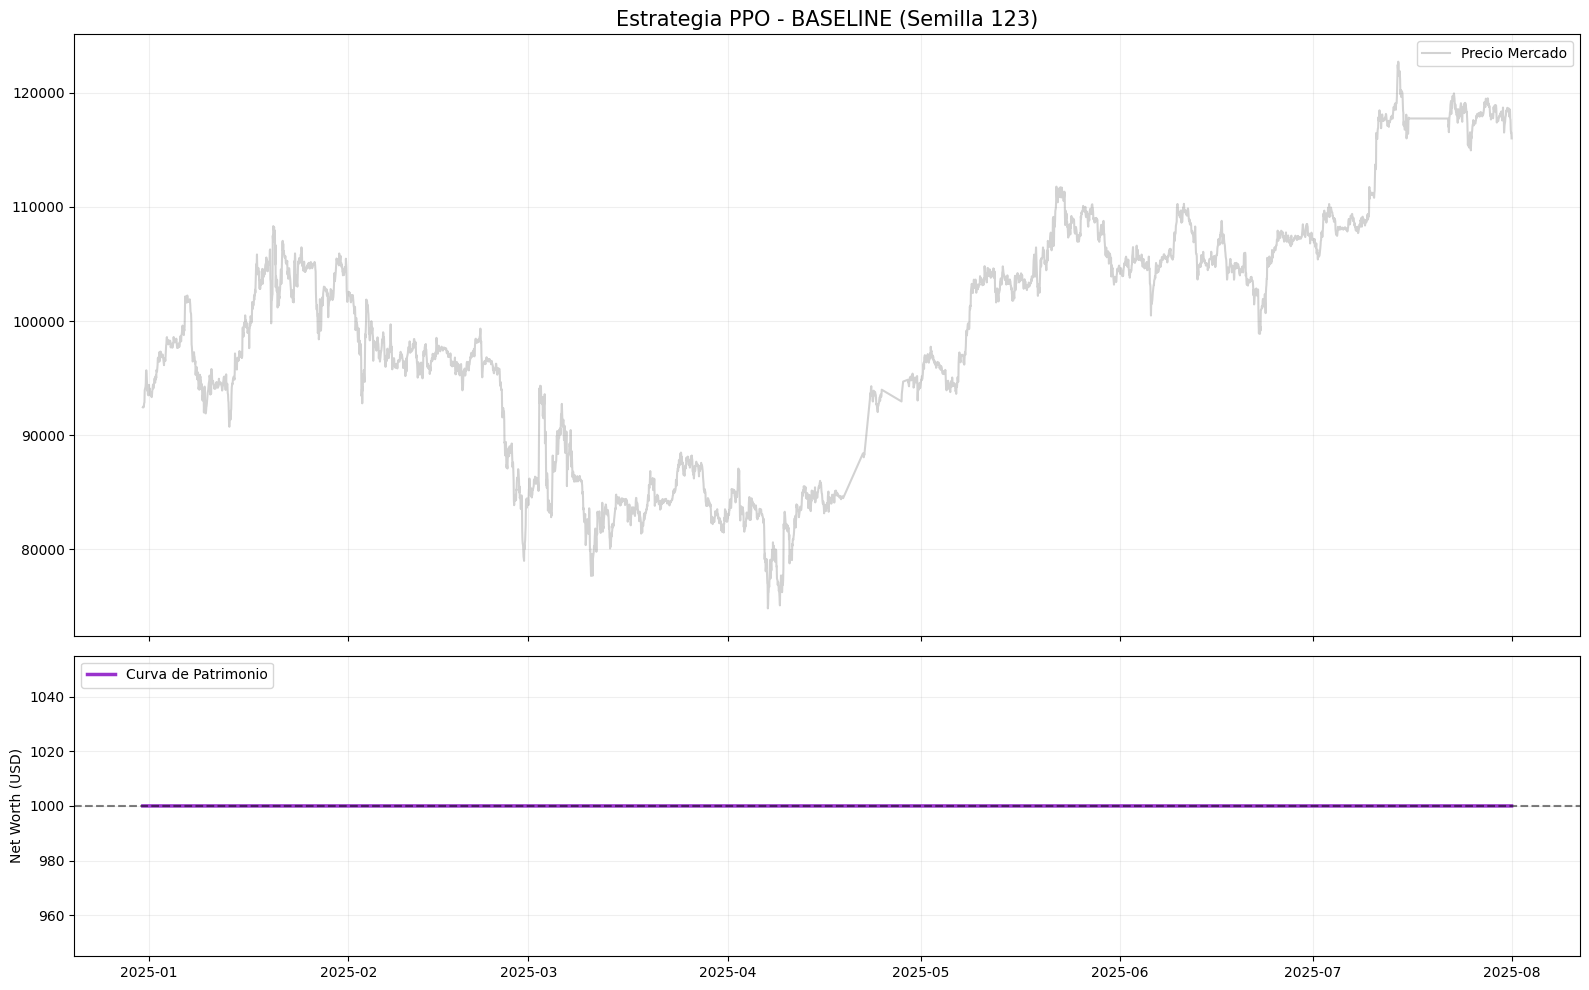


 📊 REPORTE VISUAL PPO: BASELINE | SEED: 456
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   0
📉 Entradas Short:  0
✖️  Cierres (Out):   0
🔄 Operaciones totales: 0
----------------------------------
💰 Patrimonio Final: $1000.00
📊 Retorno IA:       0.00%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -25.50%


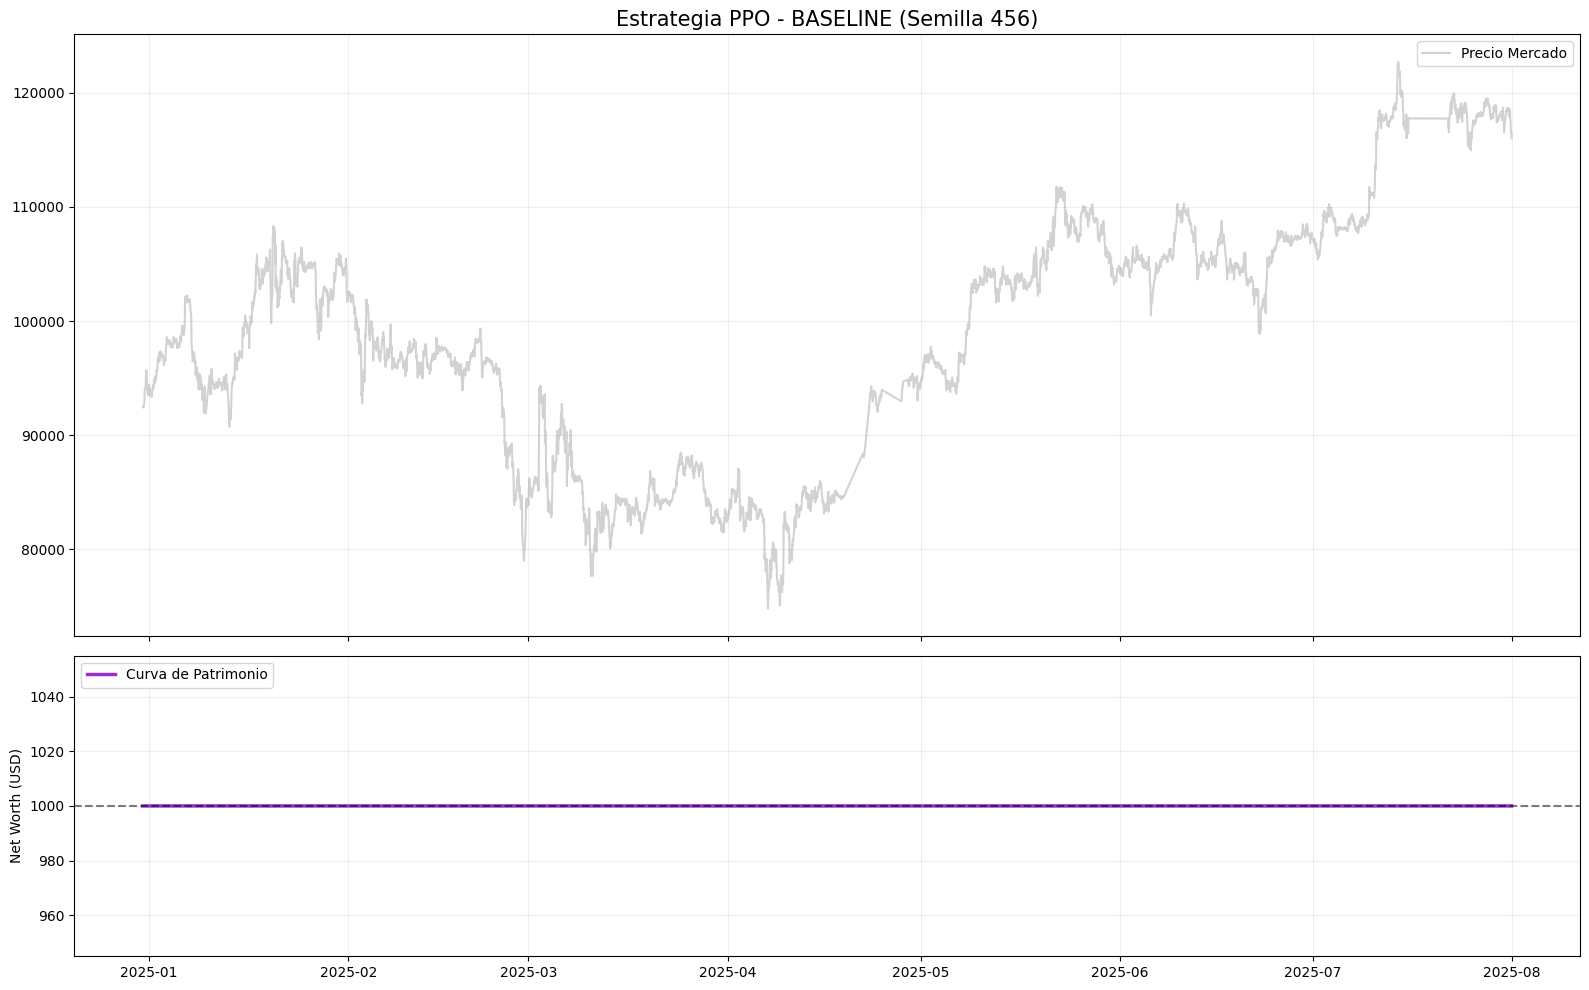


 📊 REPORTE VISUAL PPO: BASELINE | SEED: 789
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   10
📉 Entradas Short:  9
✖️  Cierres (Out):   13
🔄 Operaciones totales: 32
----------------------------------
💰 Patrimonio Final: $783.95
📊 Retorno IA:       -21.61%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -47.11%


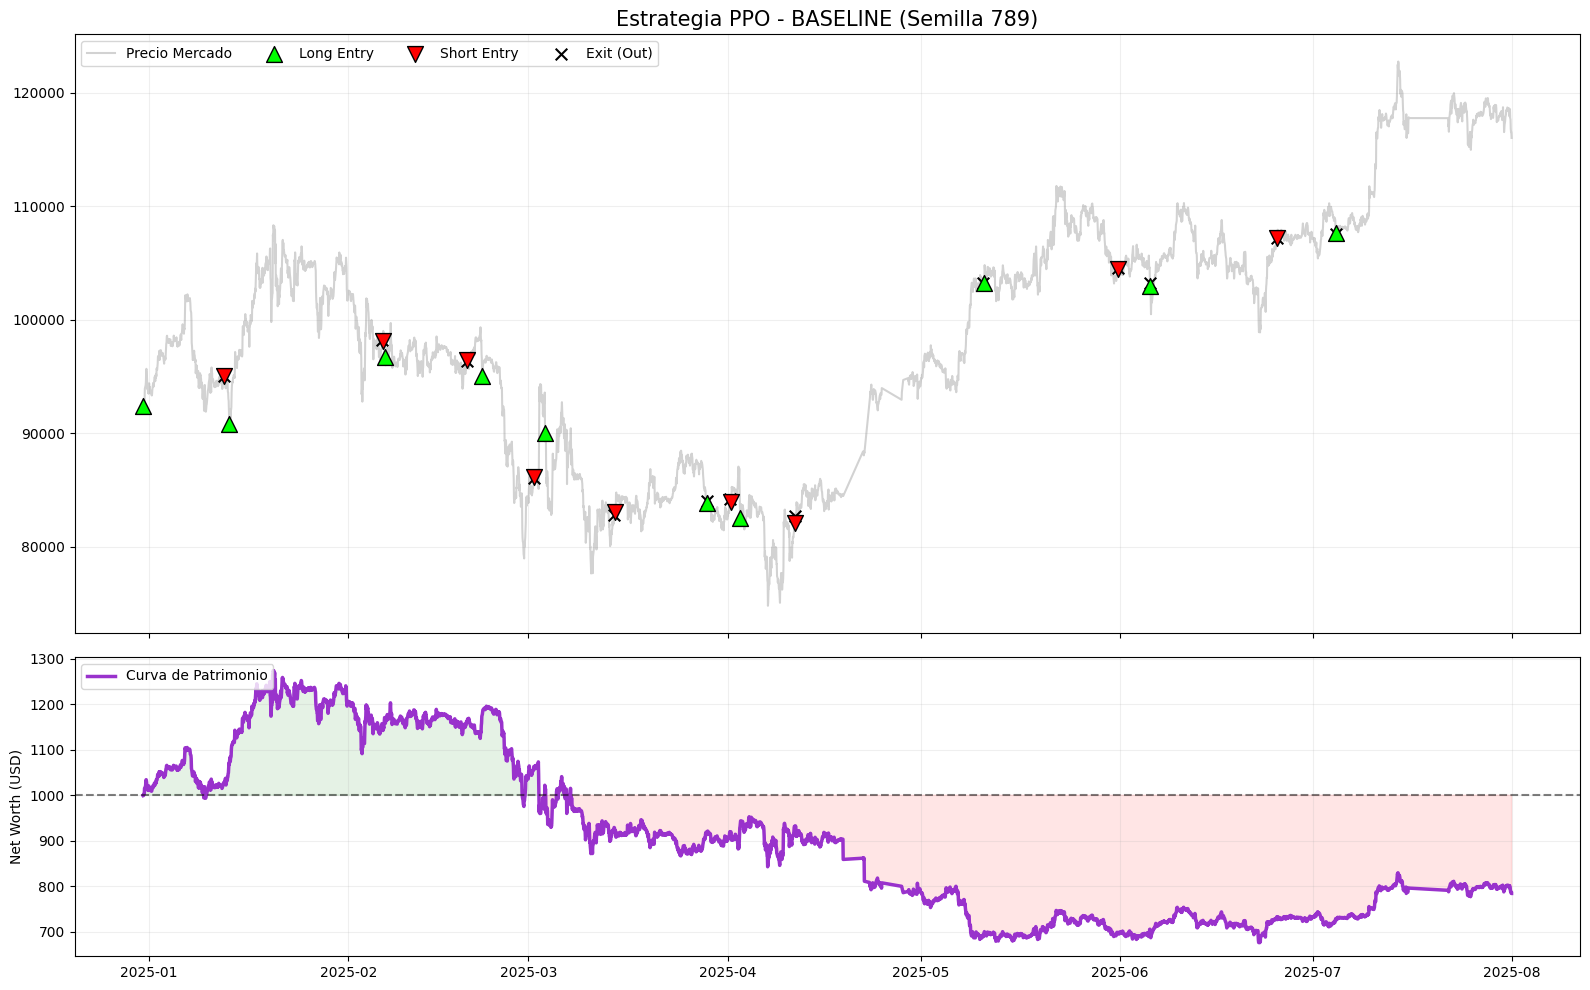


 📊 REPORTE VISUAL PPO: BASELINE | SEED: 1011
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   3
📉 Entradas Short:  0
✖️  Cierres (Out):   3
🔄 Operaciones totales: 6
----------------------------------
💰 Patrimonio Final: $1136.41
📊 Retorno IA:       13.64%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -11.86%


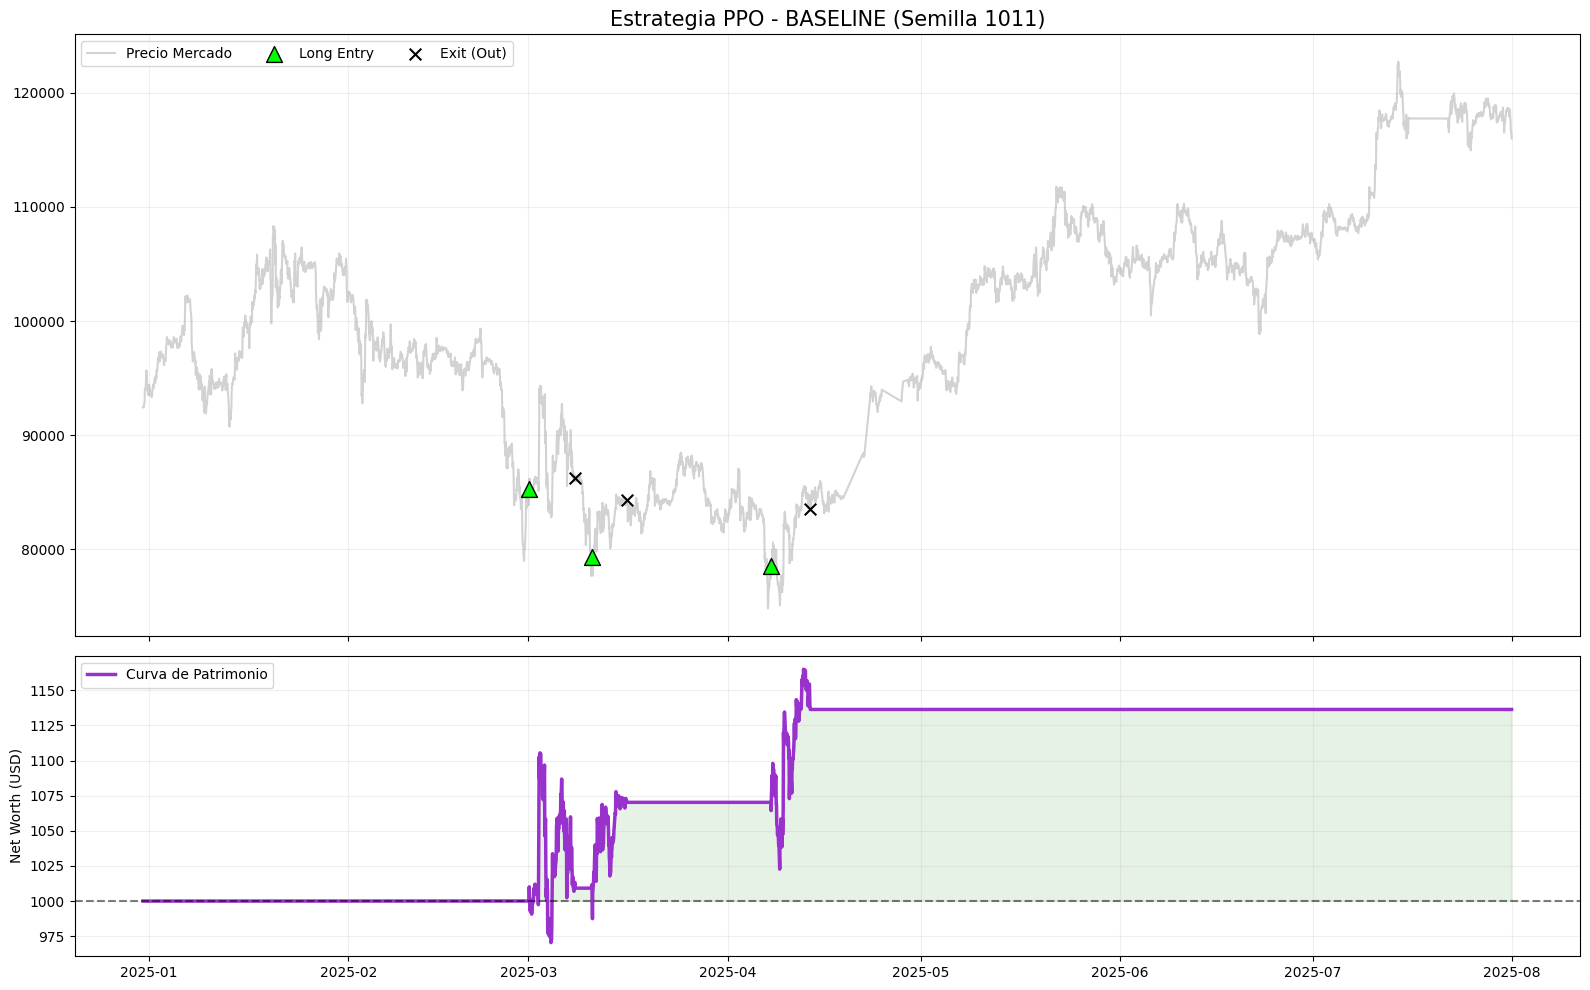


 📊 REPORTE VISUAL PPO: TEMPORAL-AE | SEED: 42
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   19
📉 Entradas Short:  0
✖️  Cierres (Out):   18
🔄 Operaciones totales: 37
----------------------------------
💰 Patrimonio Final: $977.54
📊 Retorno IA:       -2.25%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -27.75%


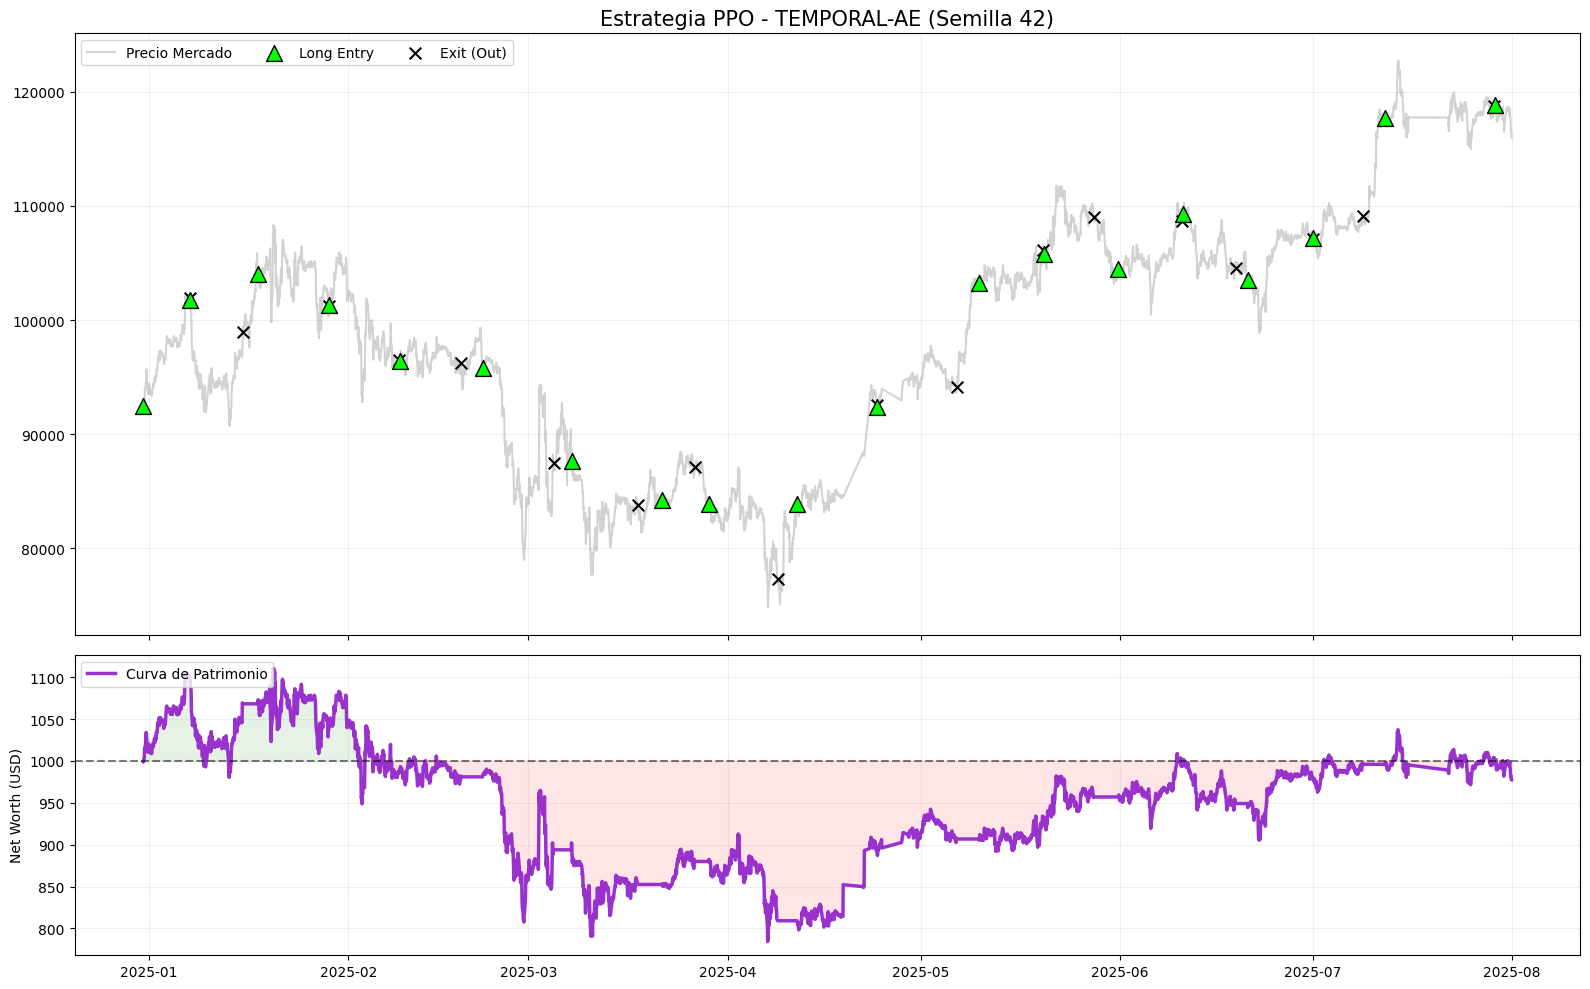


 📊 REPORTE VISUAL PPO: TEMPORAL-AE | SEED: 123
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   0
📉 Entradas Short:  0
✖️  Cierres (Out):   0
🔄 Operaciones totales: 0
----------------------------------
💰 Patrimonio Final: $1000.00
📊 Retorno IA:       0.00%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -25.50%


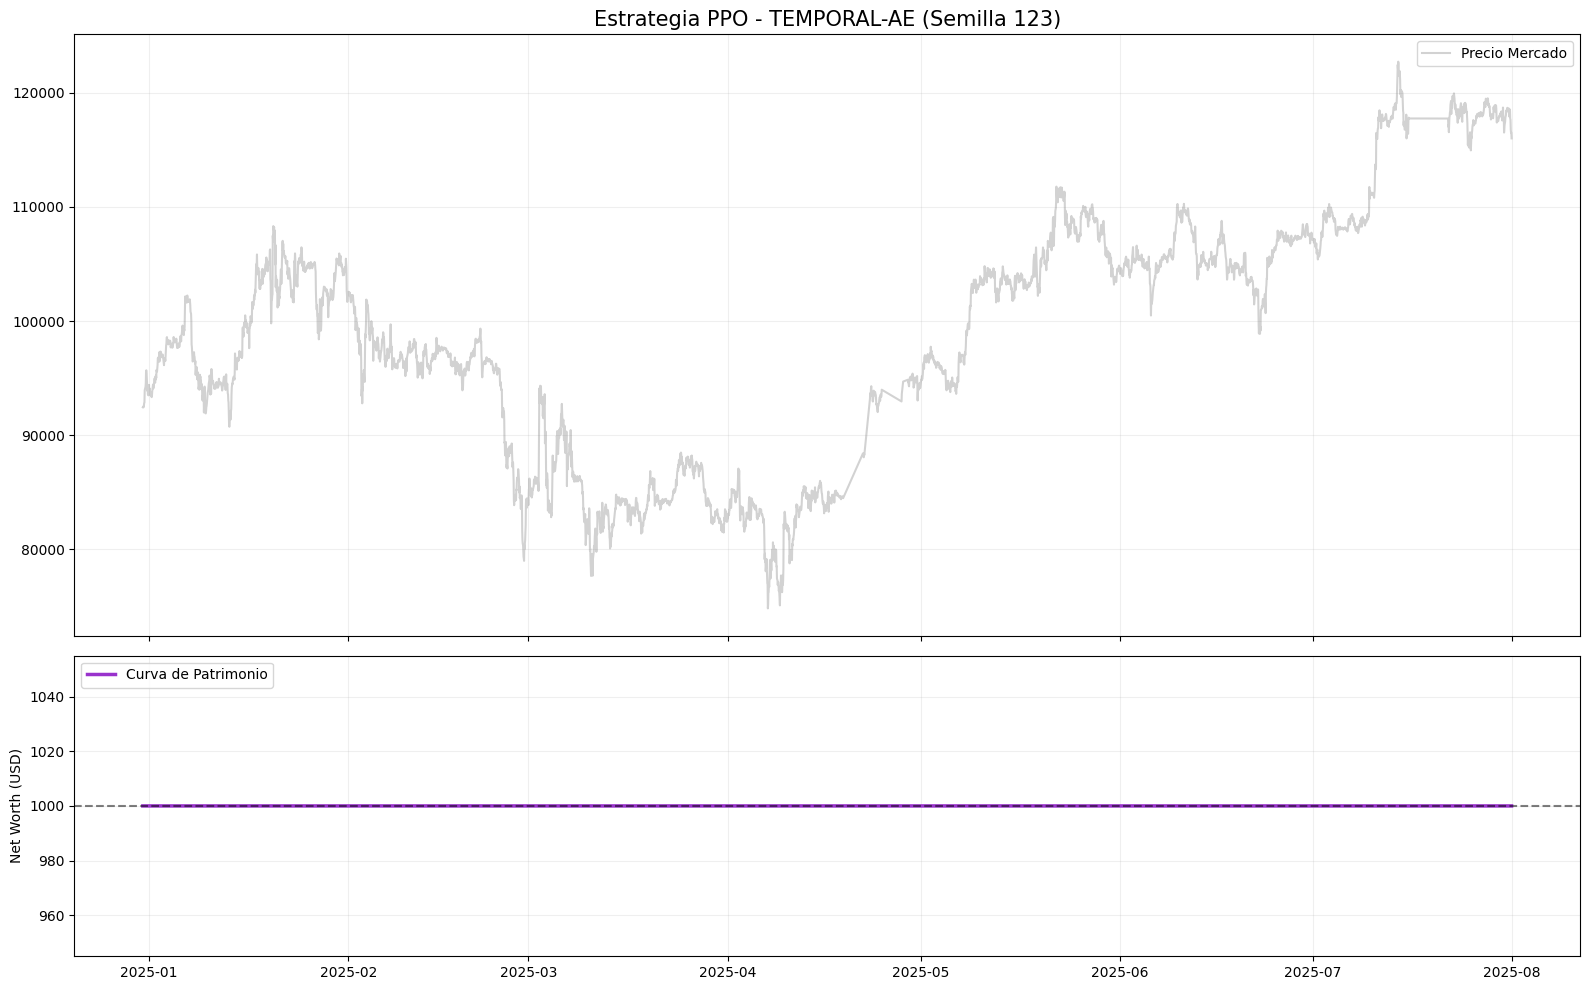


 📊 REPORTE VISUAL PPO: TEMPORAL-AE | SEED: 456
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   0
📉 Entradas Short:  0
✖️  Cierres (Out):   0
🔄 Operaciones totales: 0
----------------------------------
💰 Patrimonio Final: $1000.00
📊 Retorno IA:       0.00%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -25.50%


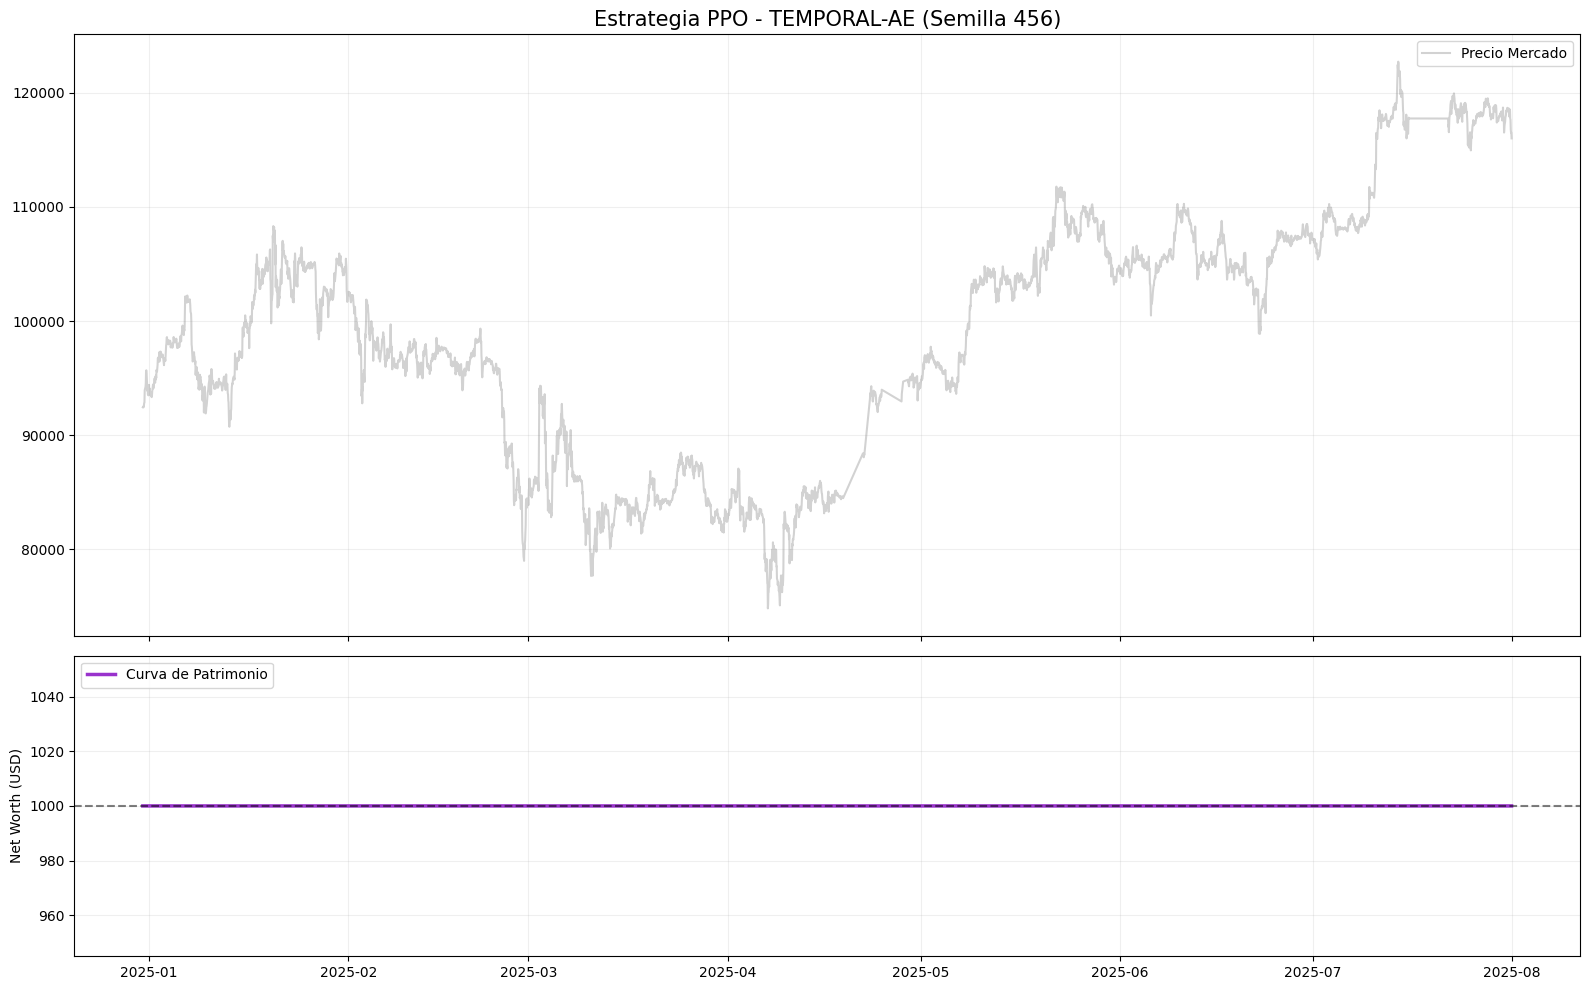


 📊 REPORTE VISUAL PPO: TEMPORAL-AE | SEED: 789
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   23
📉 Entradas Short:  9
✖️  Cierres (Out):   31
🔄 Operaciones totales: 63
----------------------------------
💰 Patrimonio Final: $1078.10
📊 Retorno IA:       7.81%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -17.69%


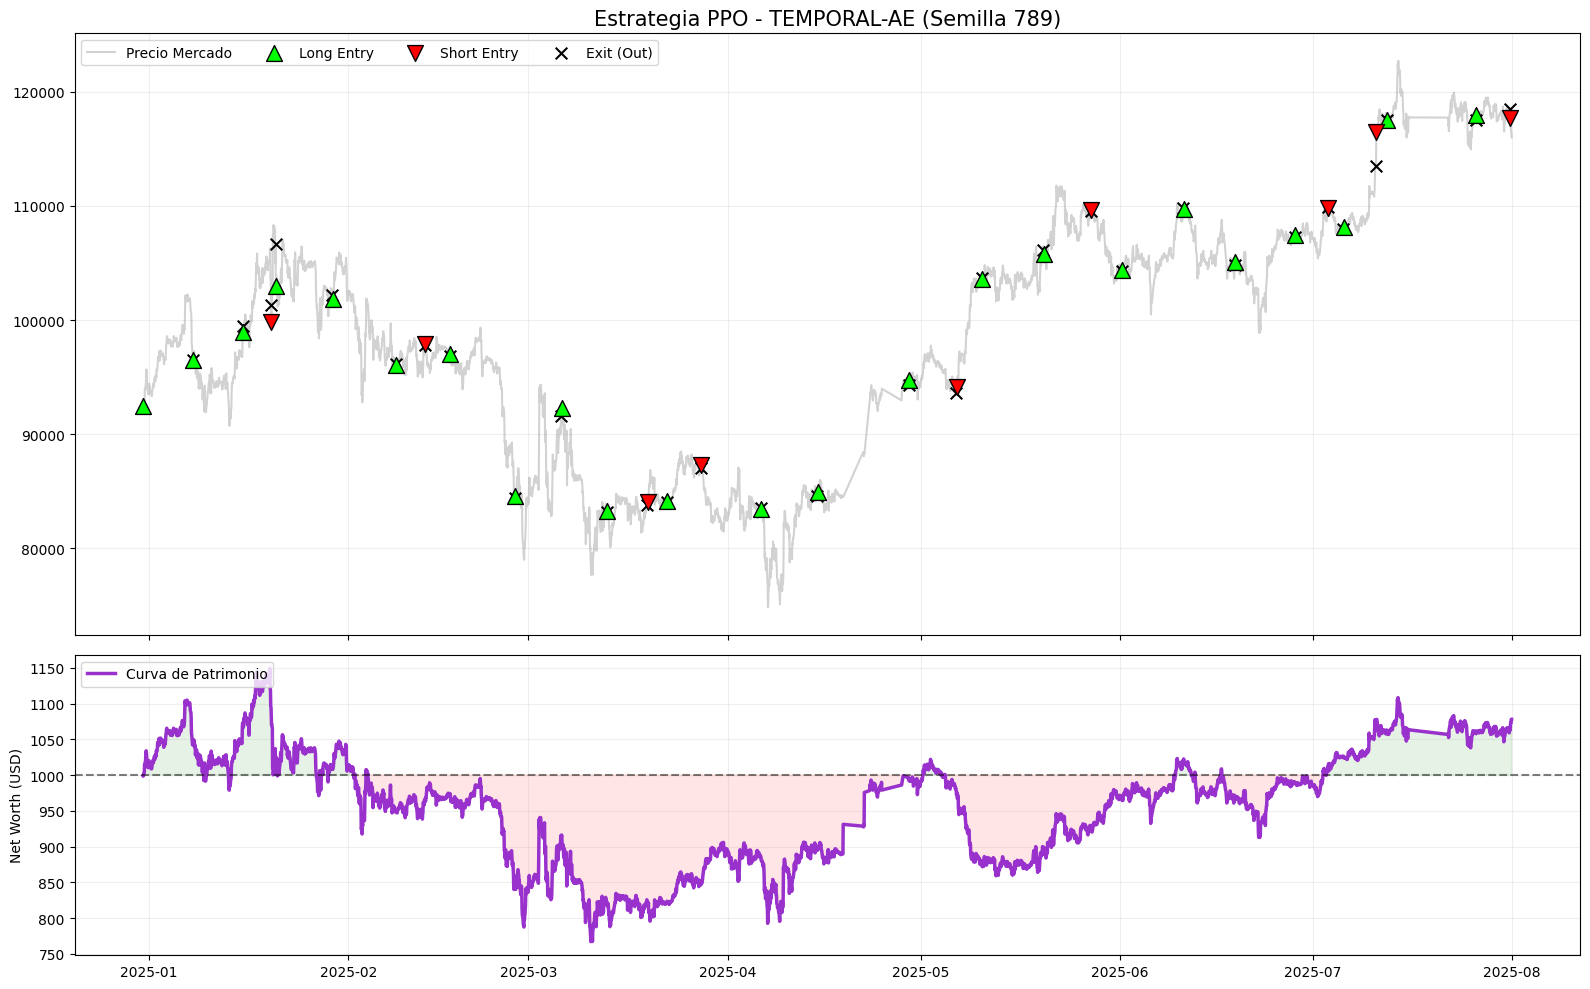


 📊 REPORTE VISUAL PPO: TEMPORAL-AE | SEED: 1011
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   11
📉 Entradas Short:  0
✖️  Cierres (Out):   10
🔄 Operaciones totales: 21
----------------------------------
💰 Patrimonio Final: $1216.66
📊 Retorno IA:       21.67%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -3.84%


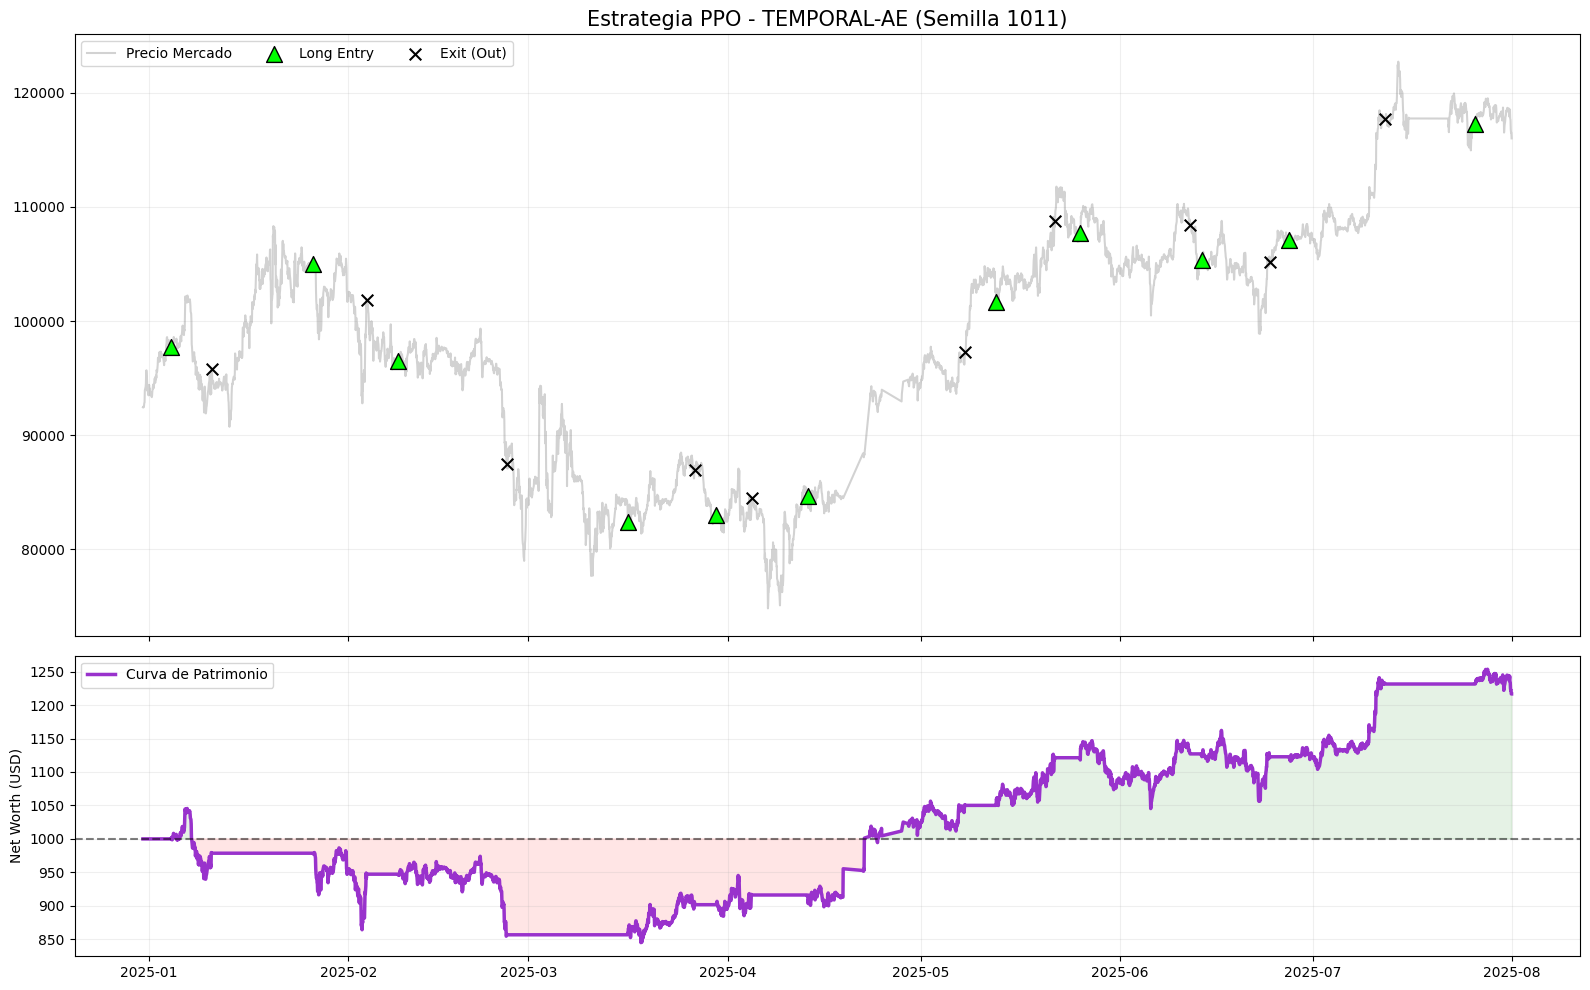


 📊 REPORTE VISUAL PPO: CPC | SEED: 42
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   76
📉 Entradas Short:  0
✖️  Cierres (Out):   76
🔄 Operaciones totales: 152
----------------------------------
💰 Patrimonio Final: $1771.32
📊 Retorno IA:       77.13%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   51.63%


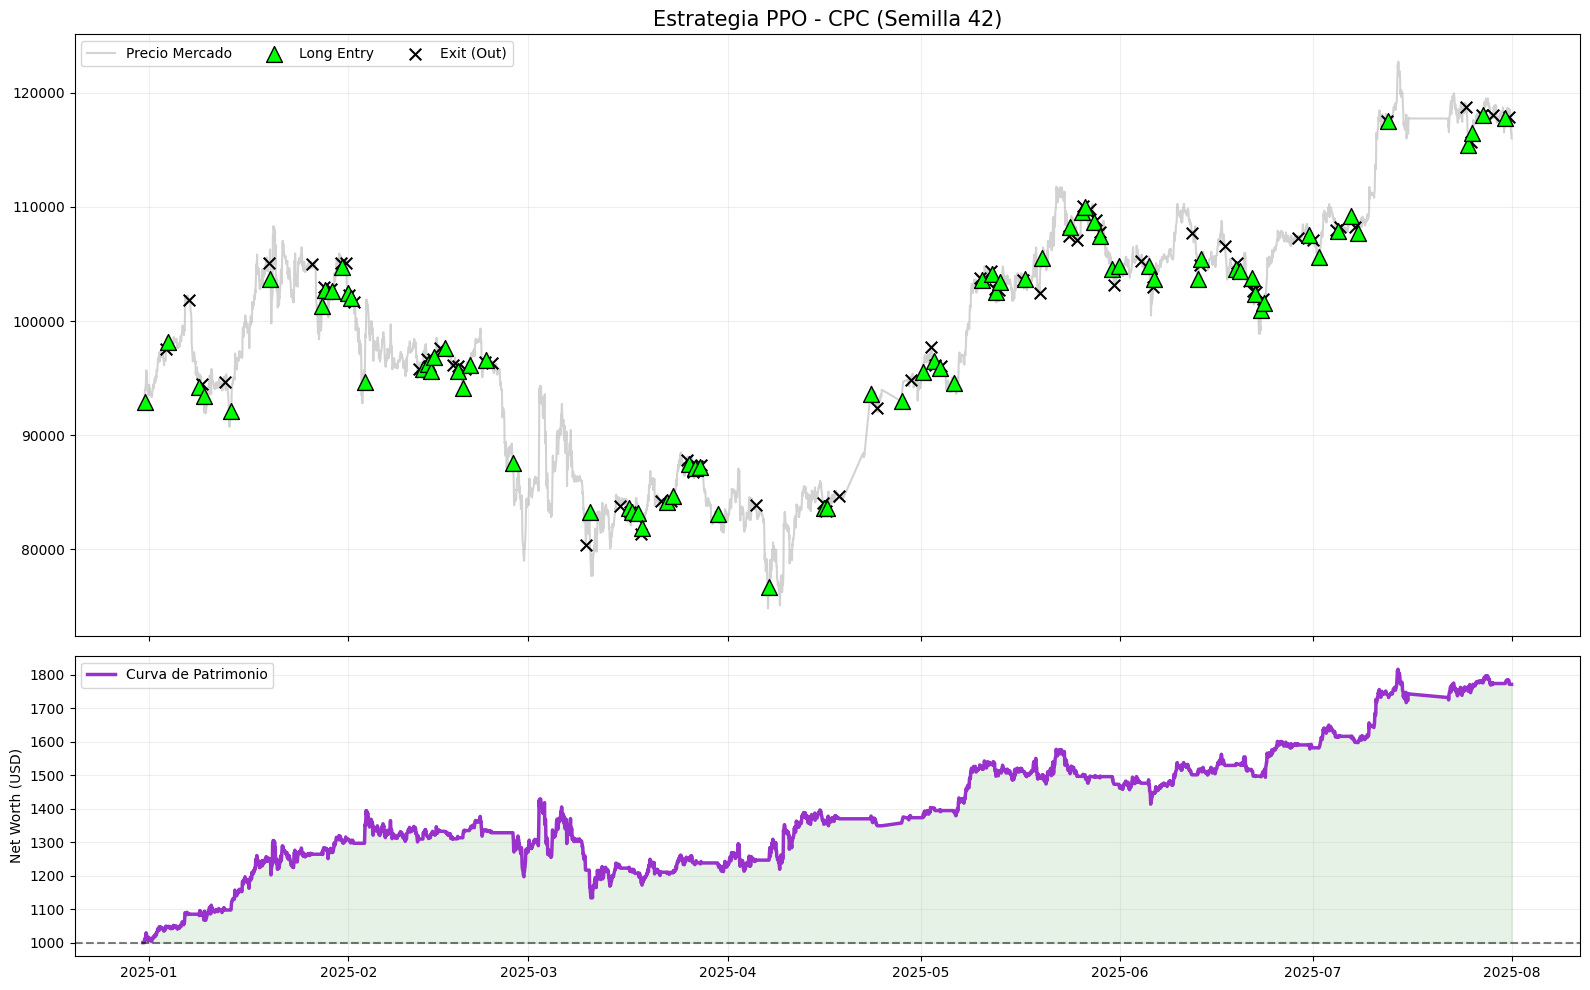


 📊 REPORTE VISUAL PPO: CPC | SEED: 123
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   66
📉 Entradas Short:  56
✖️  Cierres (Out):   110
🔄 Operaciones totales: 232
----------------------------------
💰 Patrimonio Final: $1338.74
📊 Retorno IA:       33.87%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   8.37%


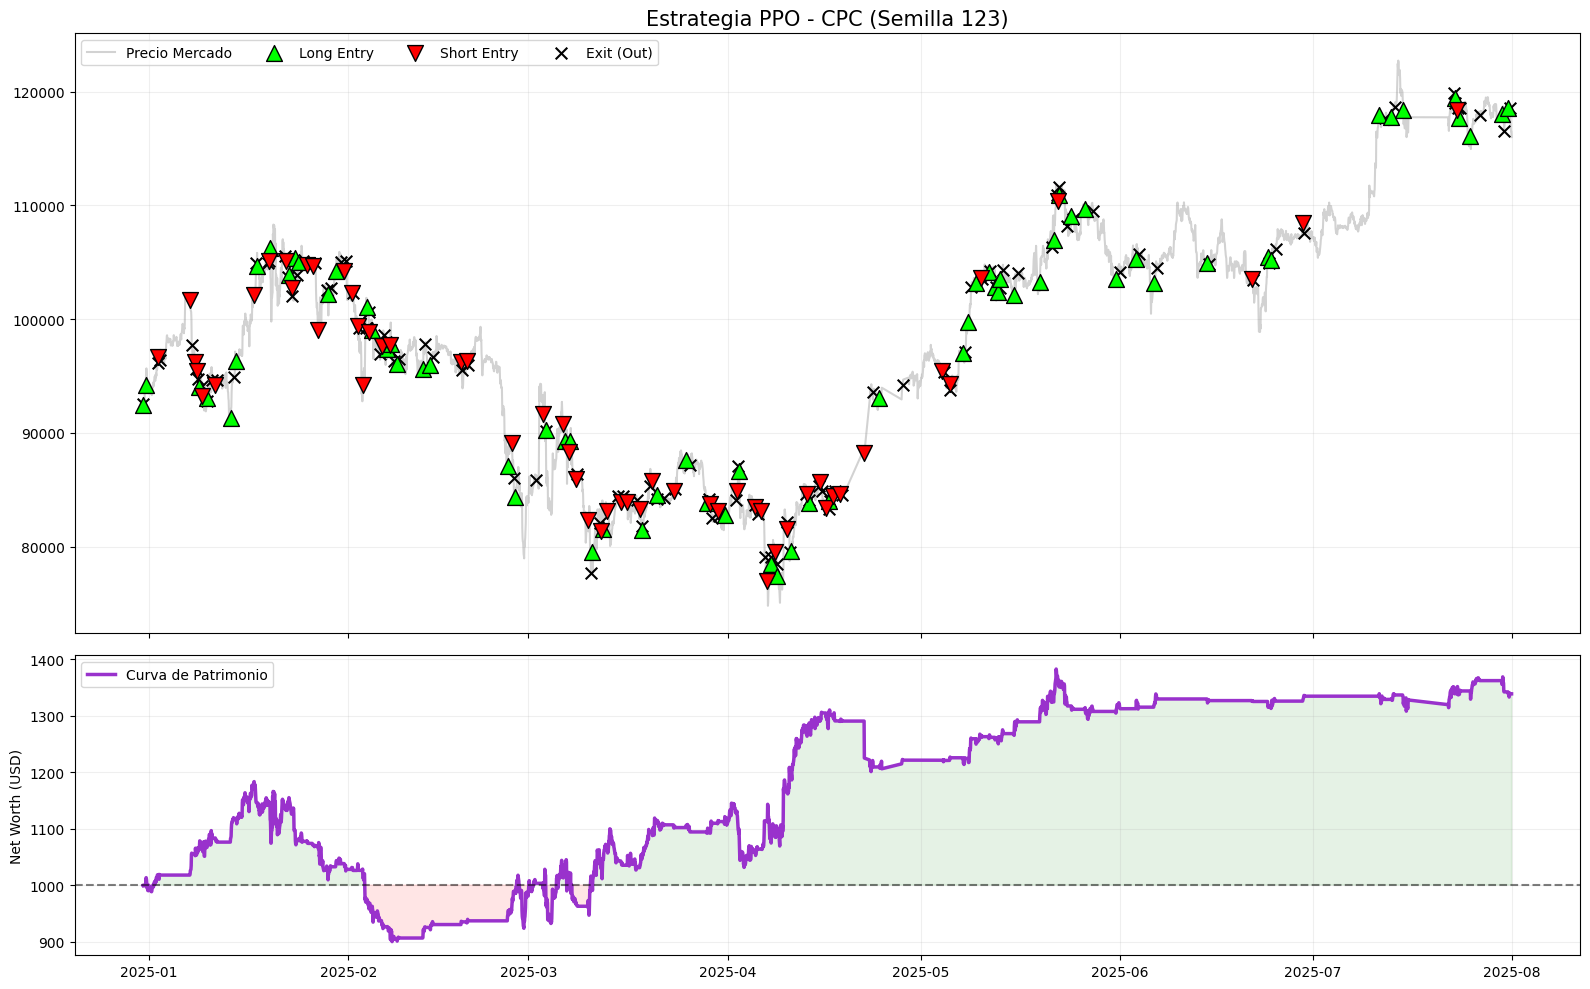


 📊 REPORTE VISUAL PPO: CPC | SEED: 456
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   0
📉 Entradas Short:  0
✖️  Cierres (Out):   0
🔄 Operaciones totales: 0
----------------------------------
💰 Patrimonio Final: $1000.00
📊 Retorno IA:       0.00%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -25.50%


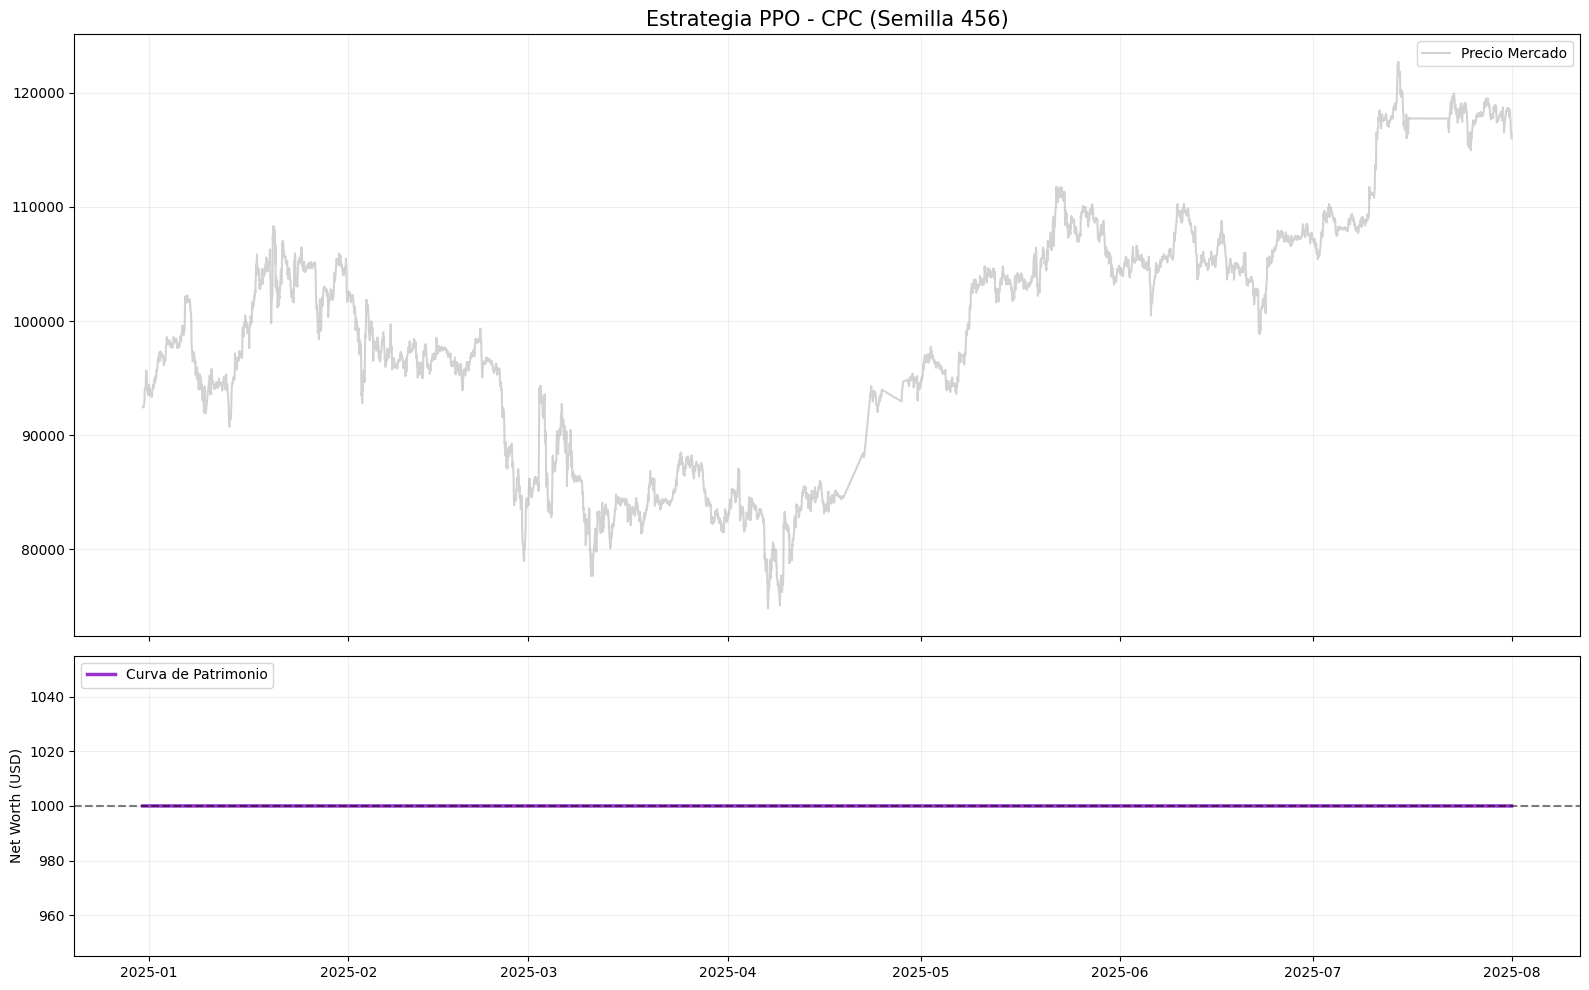


 📊 REPORTE VISUAL PPO: CPC | SEED: 789
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   98
📉 Entradas Short:  85
✖️  Cierres (Out):   159
🔄 Operaciones totales: 342
----------------------------------
💰 Patrimonio Final: $2344.26
📊 Retorno IA:       134.43%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   108.92%


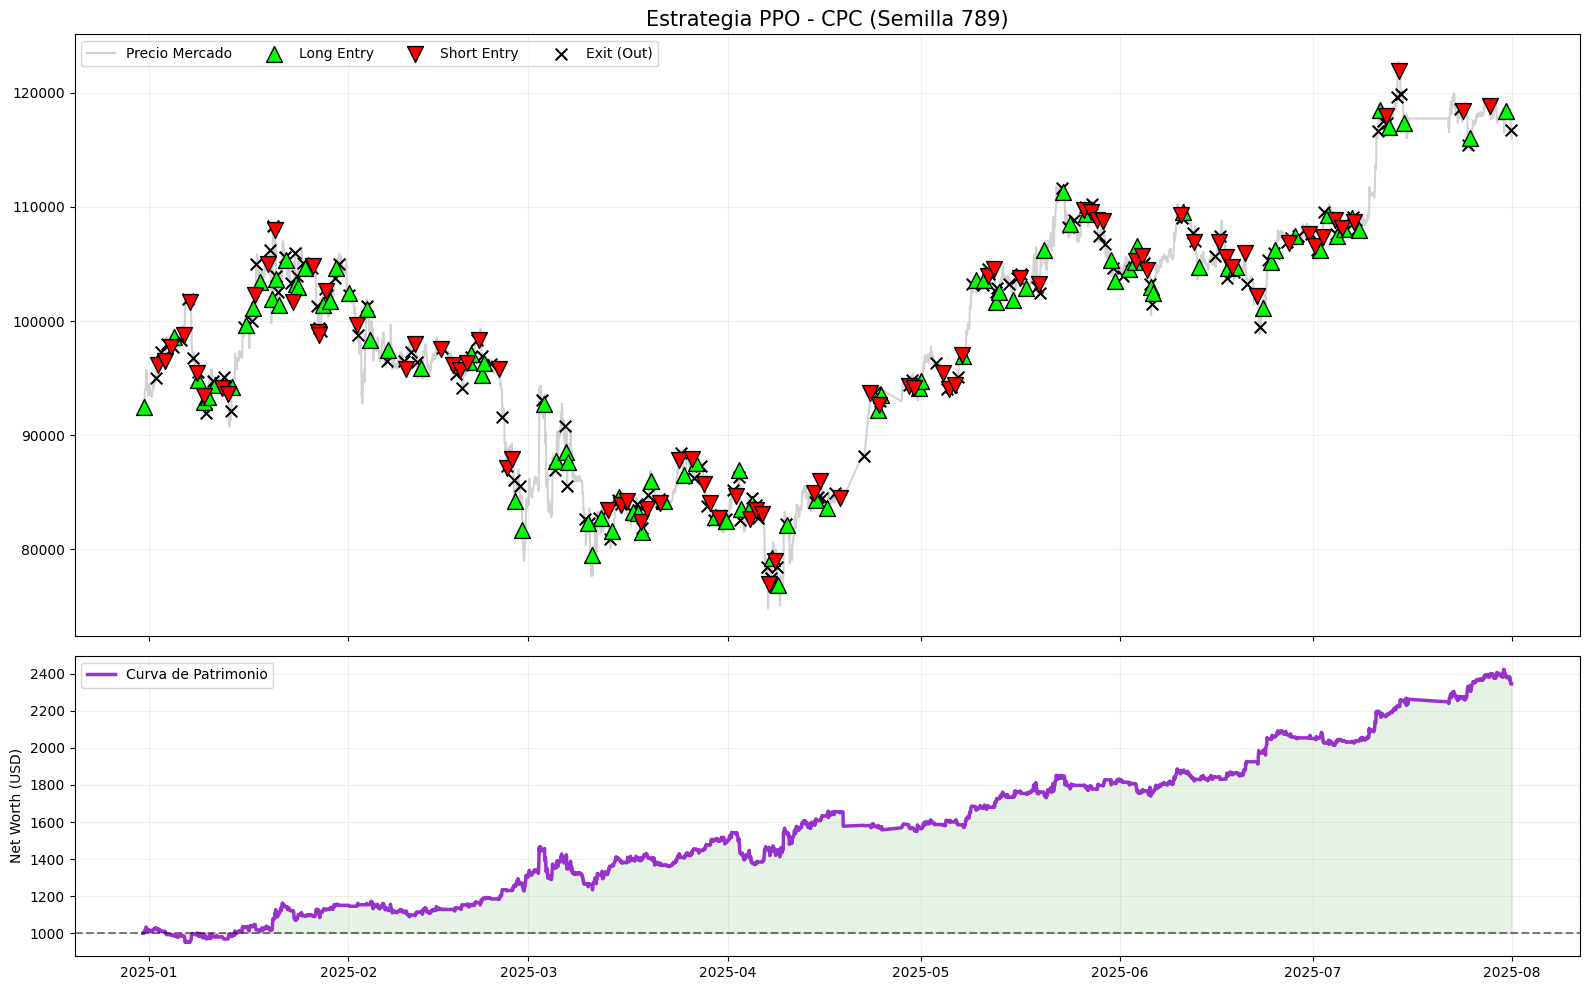


 📊 REPORTE VISUAL PPO: CPC | SEED: 1011
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   110
📉 Entradas Short:  107
✖️  Cierres (Out):   206
🔄 Operaciones totales: 423
----------------------------------
💰 Patrimonio Final: $1841.07
📊 Retorno IA:       84.11%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   58.60%


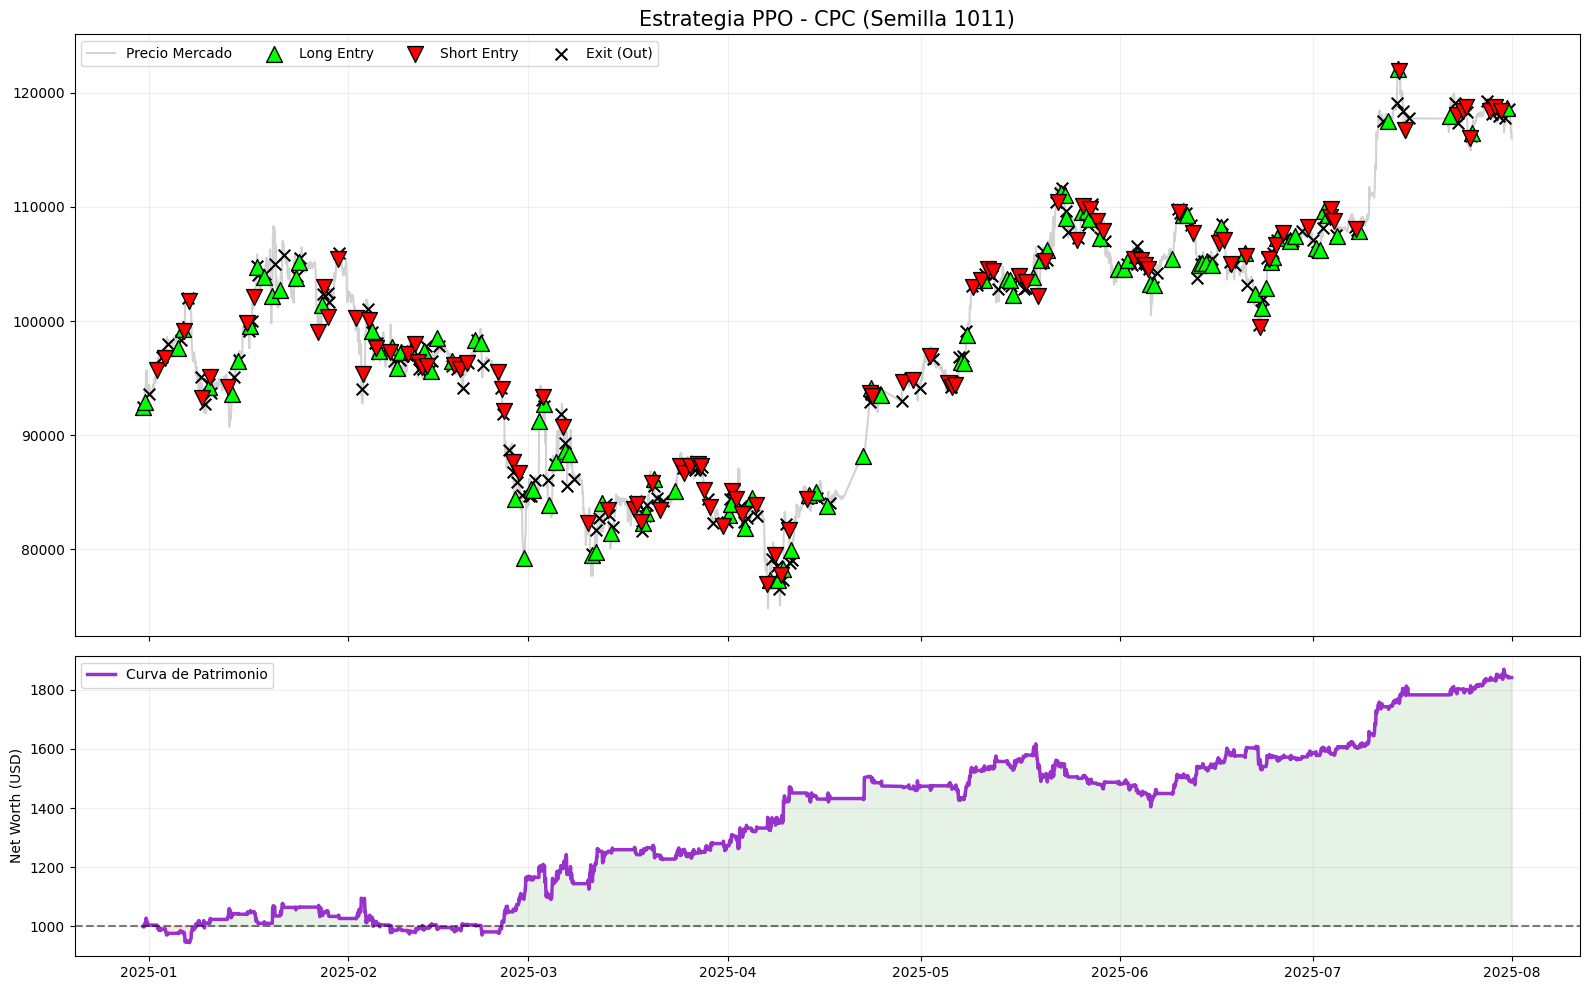


 📊 REPORTE VISUAL PPO: TRANSFORMER | SEED: 42
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   0
📉 Entradas Short:  0
✖️  Cierres (Out):   0
🔄 Operaciones totales: 0
----------------------------------
💰 Patrimonio Final: $1000.00
📊 Retorno IA:       0.00%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -25.50%


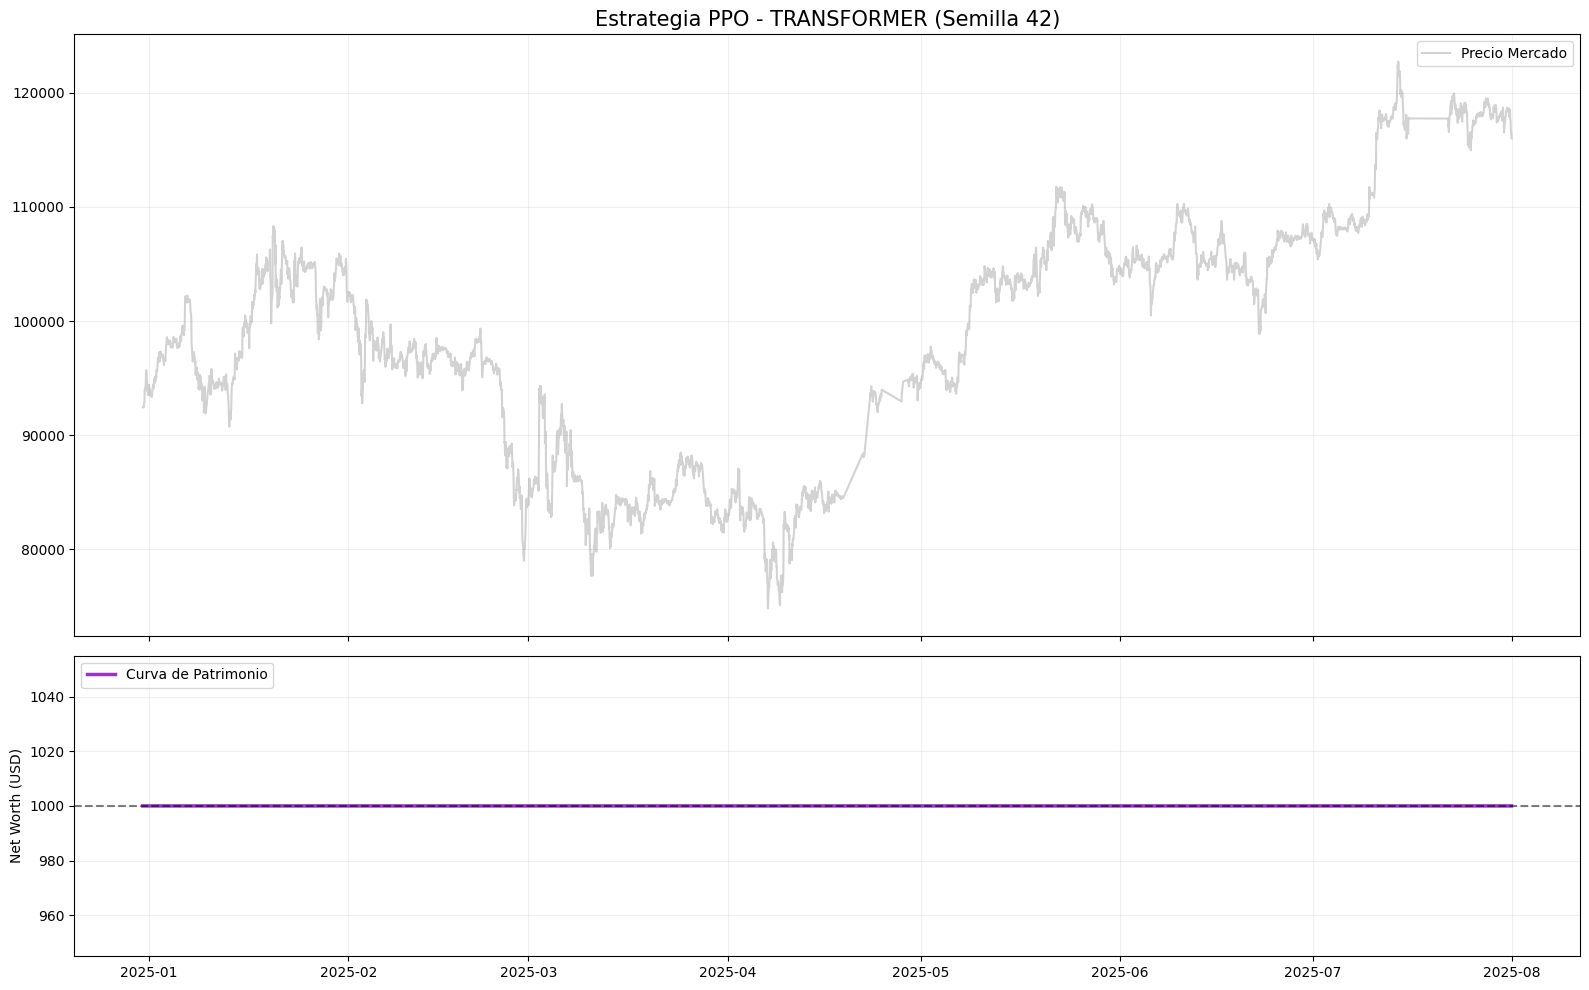


 📊 REPORTE VISUAL PPO: TRANSFORMER | SEED: 123
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   0
📉 Entradas Short:  0
✖️  Cierres (Out):   0
🔄 Operaciones totales: 0
----------------------------------
💰 Patrimonio Final: $1000.00
📊 Retorno IA:       0.00%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -25.50%


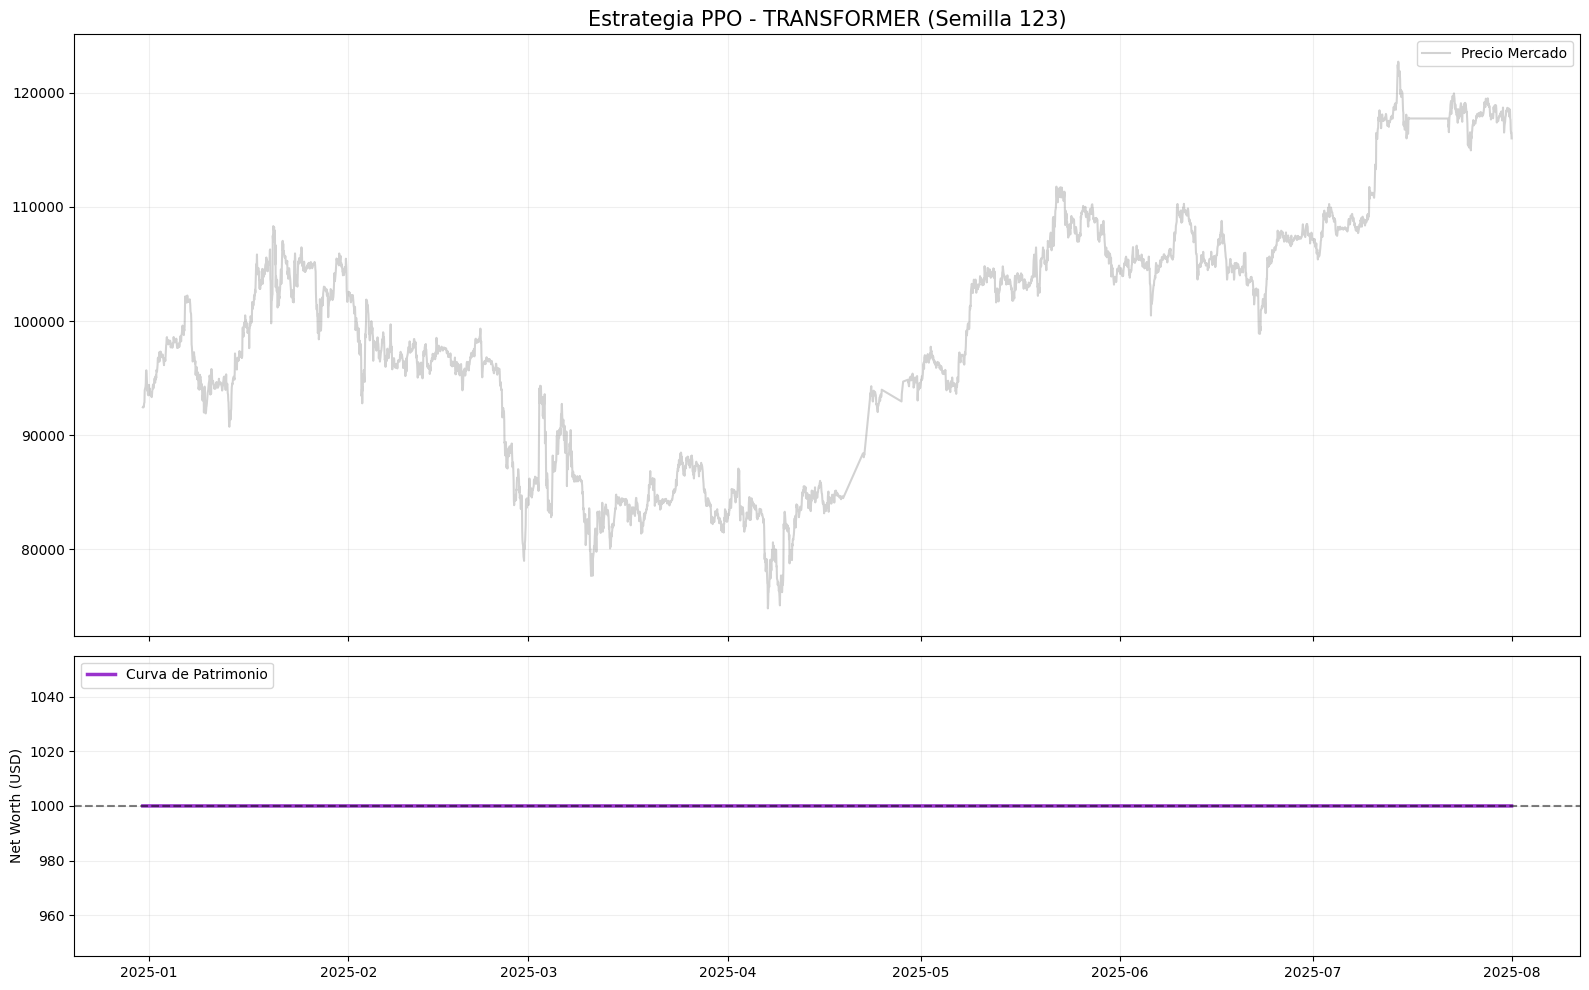


 📊 REPORTE VISUAL PPO: TRANSFORMER | SEED: 456
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   0
📉 Entradas Short:  0
✖️  Cierres (Out):   0
🔄 Operaciones totales: 0
----------------------------------
💰 Patrimonio Final: $1000.00
📊 Retorno IA:       0.00%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -25.50%


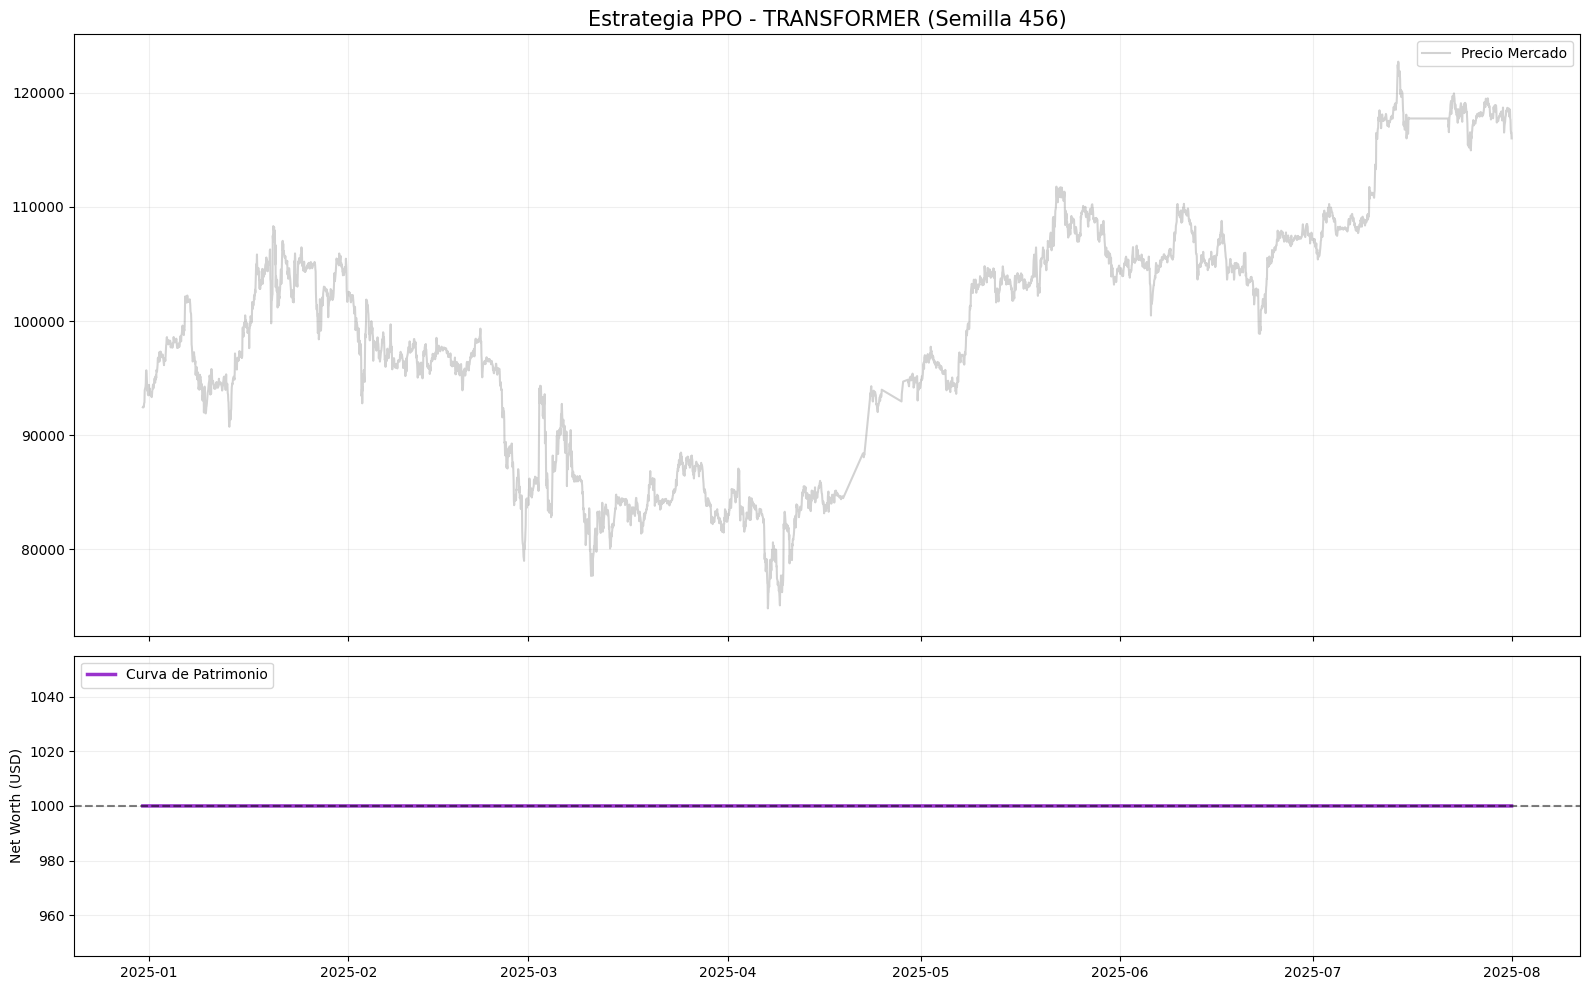


 📊 REPORTE VISUAL PPO: TRANSFORMER | SEED: 789
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   0
📉 Entradas Short:  0
✖️  Cierres (Out):   0
🔄 Operaciones totales: 0
----------------------------------
💰 Patrimonio Final: $1000.00
📊 Retorno IA:       0.00%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -25.50%


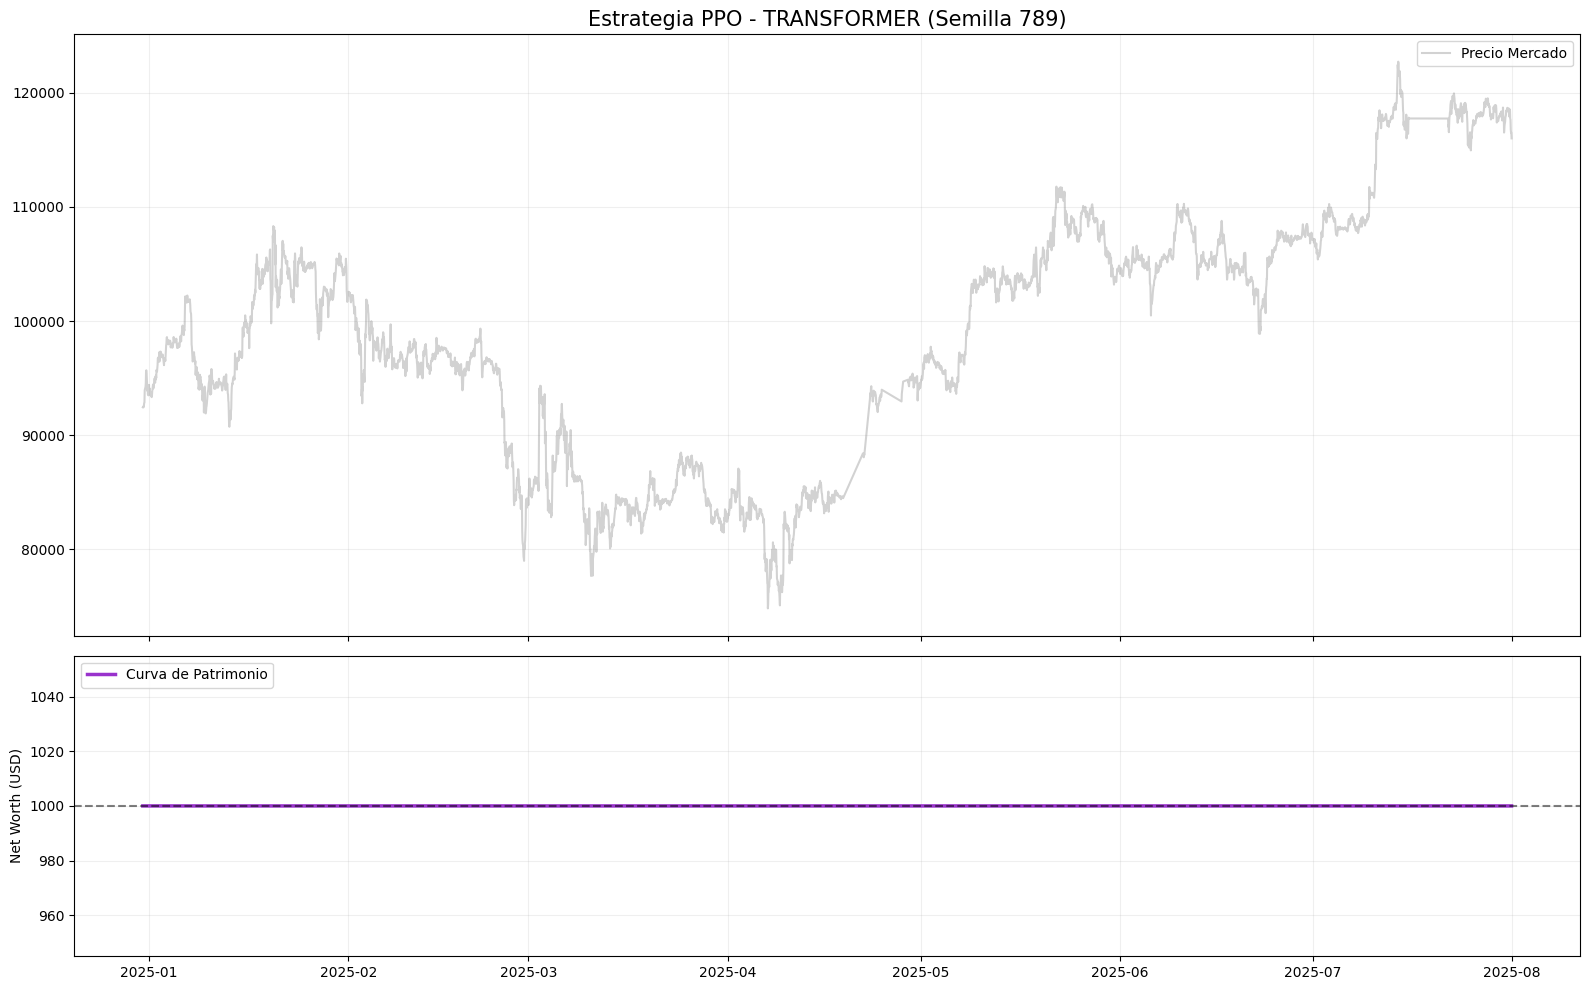


 📊 REPORTE VISUAL PPO: TRANSFORMER | SEED: 1011
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   39
📉 Entradas Short:  0
✖️  Cierres (Out):   38
🔄 Operaciones totales: 77
----------------------------------
💰 Patrimonio Final: $1264.03
📊 Retorno IA:       26.40%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   0.90%


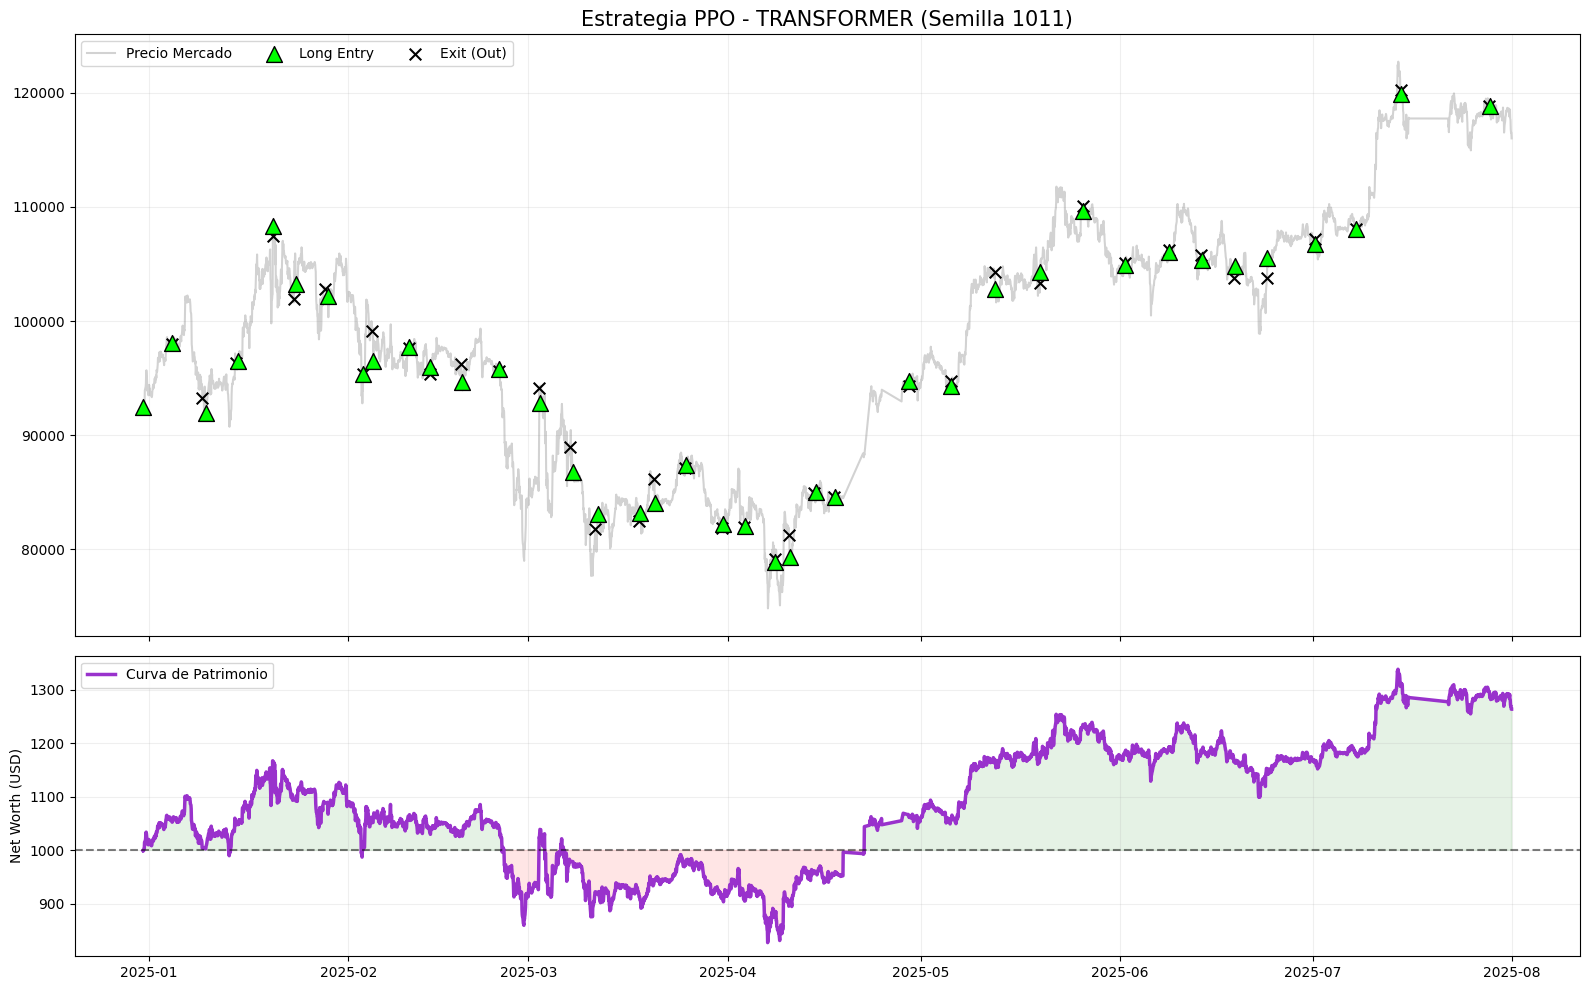


 📊 REPORTE VISUAL PPO: COMBINADO | SEED: 42
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   37
📉 Entradas Short:  72
✖️  Cierres (Out):   93
🔄 Operaciones totales: 202
----------------------------------
💰 Patrimonio Final: $1626.44
📊 Retorno IA:       62.64%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   37.14%


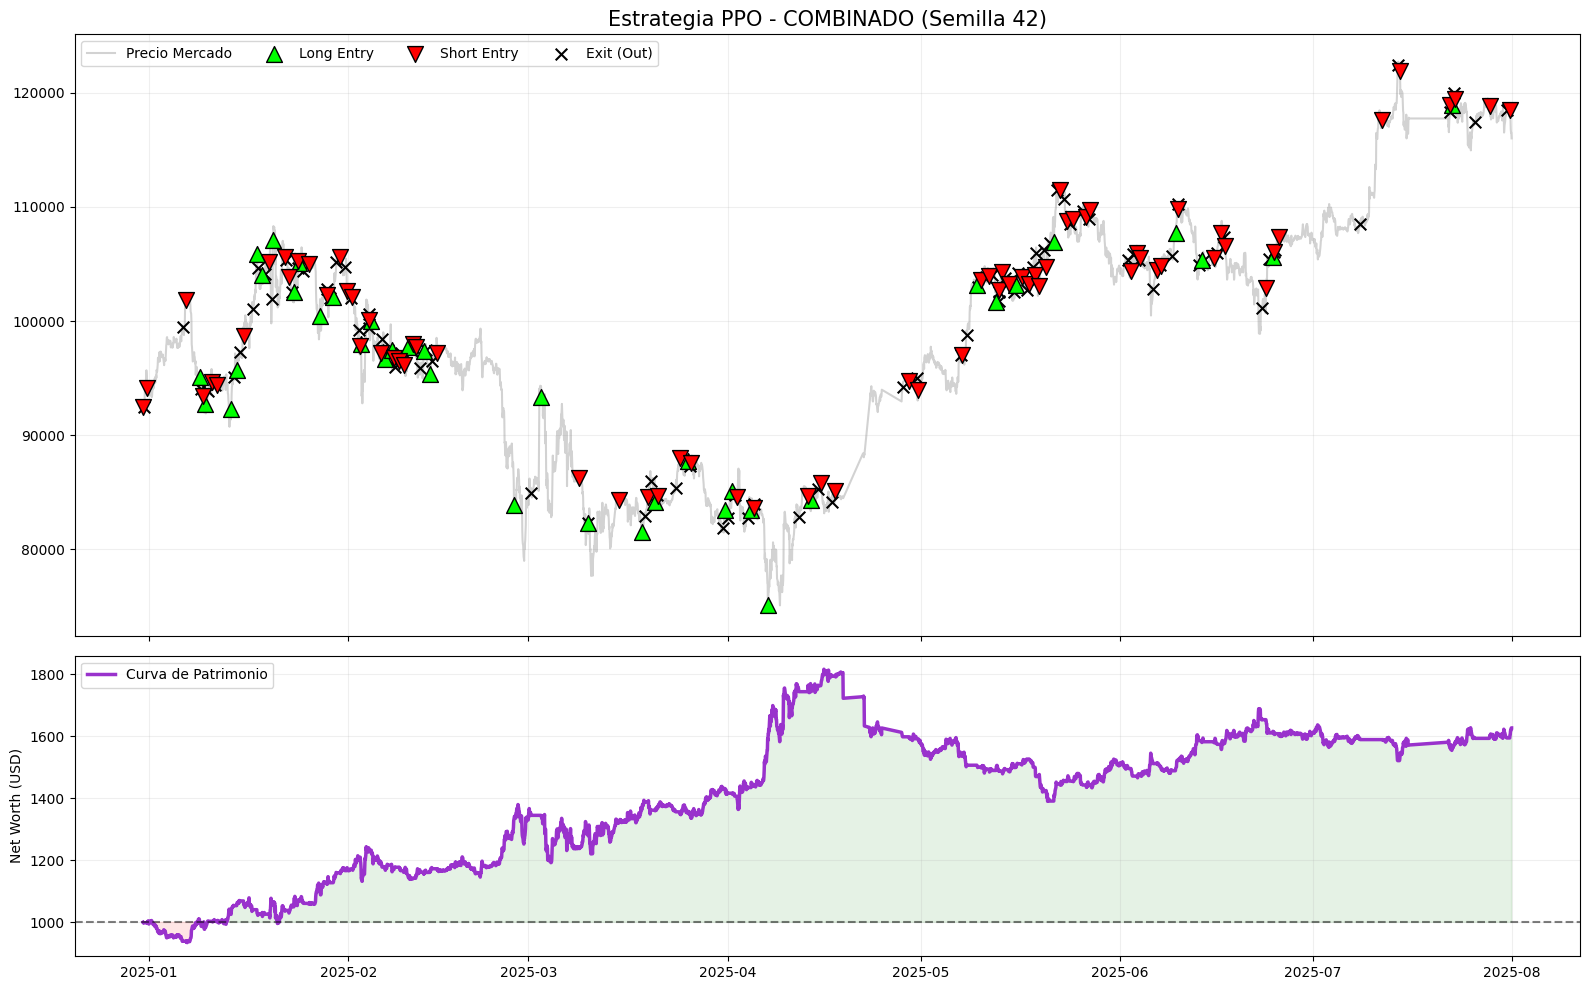


 📊 REPORTE VISUAL PPO: COMBINADO | SEED: 123
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   31
📉 Entradas Short:  42
✖️  Cierres (Out):   57
🔄 Operaciones totales: 130
----------------------------------
💰 Patrimonio Final: $806.70
📊 Retorno IA:       -19.33%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -44.83%


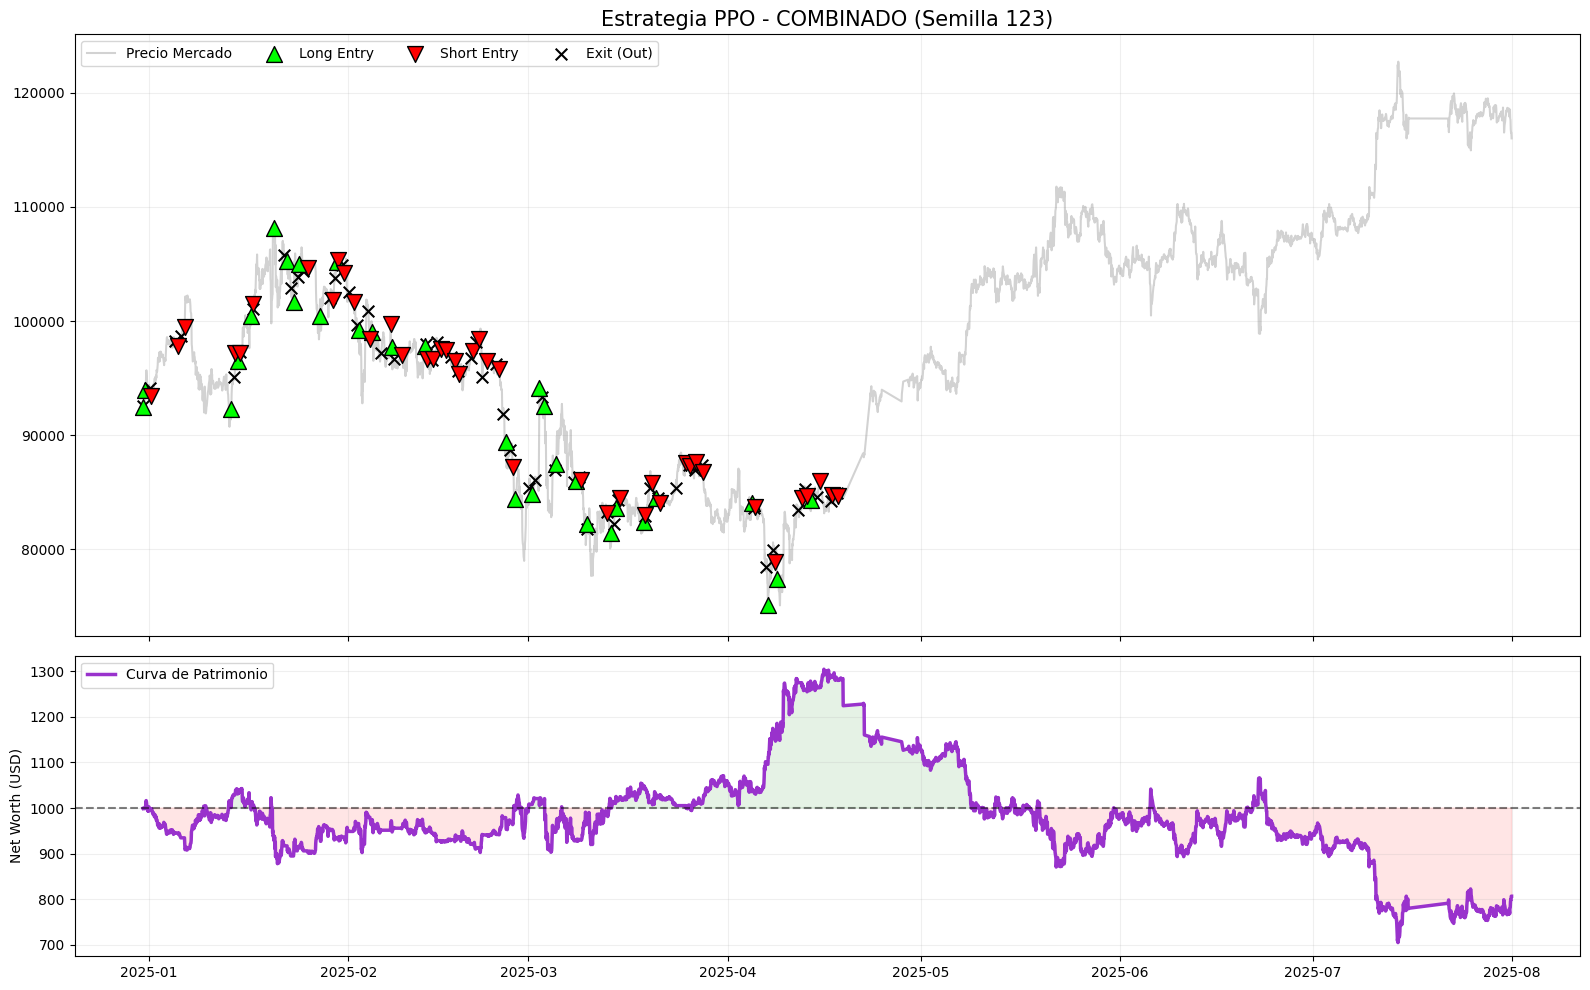


 📊 REPORTE VISUAL PPO: COMBINADO | SEED: 456
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   31
📉 Entradas Short:  13
✖️  Cierres (Out):   44
🔄 Operaciones totales: 88
----------------------------------
💰 Patrimonio Final: $869.89
📊 Retorno IA:       -13.01%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -38.51%


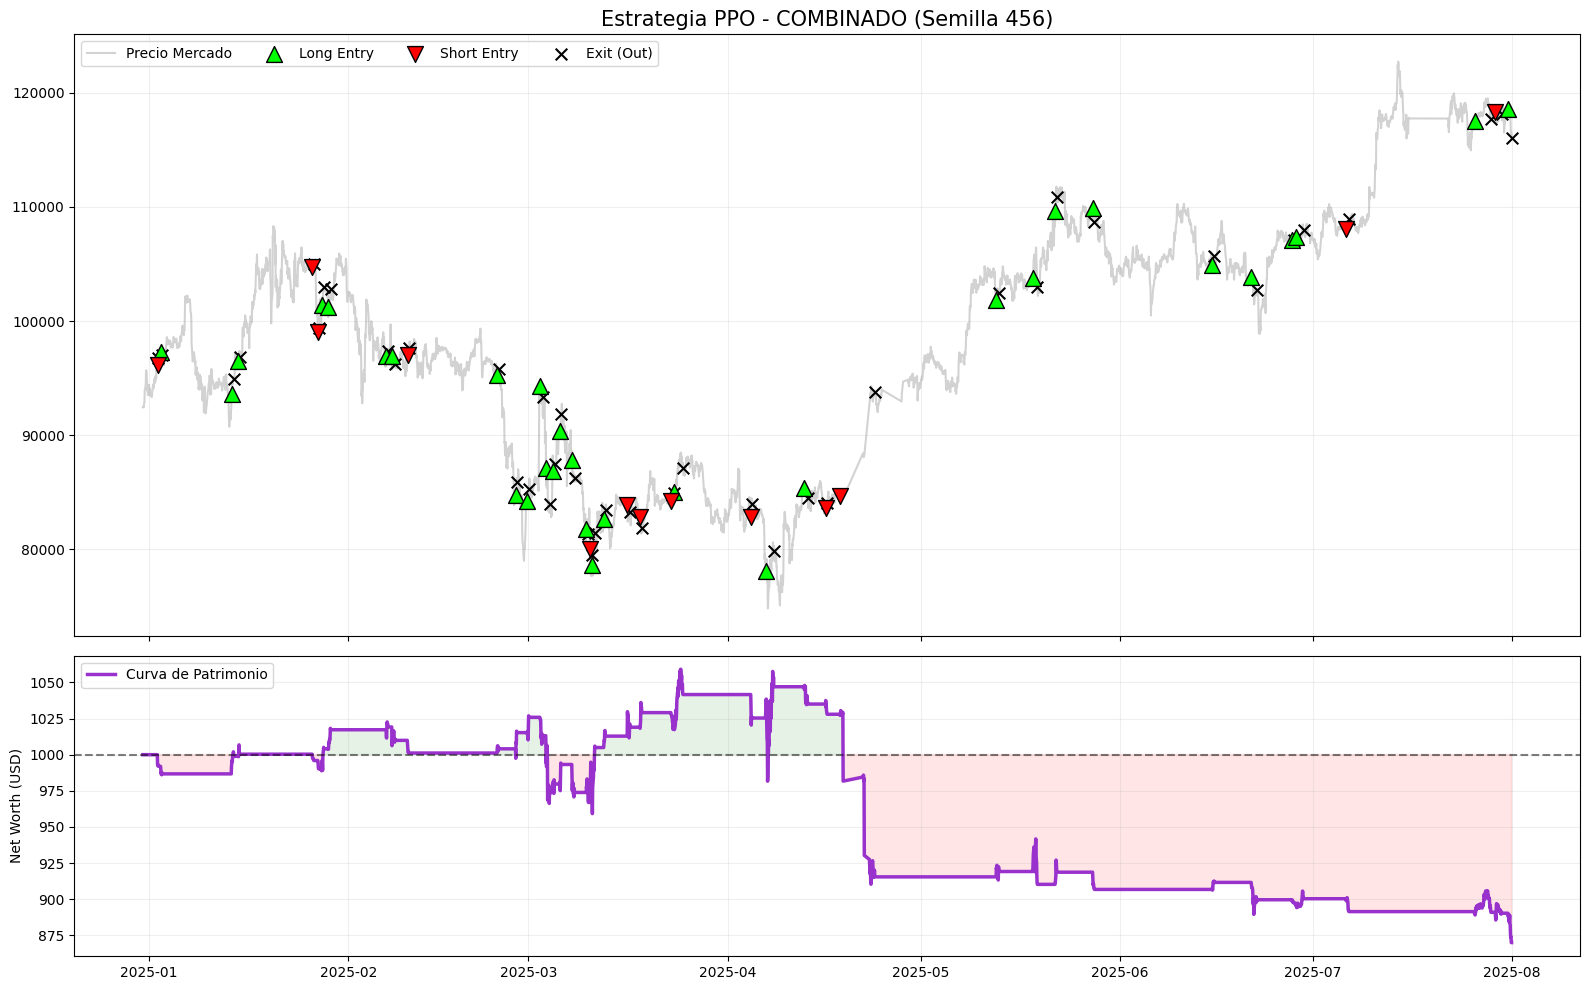


 📊 REPORTE VISUAL PPO: COMBINADO | SEED: 789
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   18
📉 Entradas Short:  62
✖️  Cierres (Out):   65
🔄 Operaciones totales: 145
----------------------------------
💰 Patrimonio Final: $1278.89
📊 Retorno IA:       27.89%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   2.38%


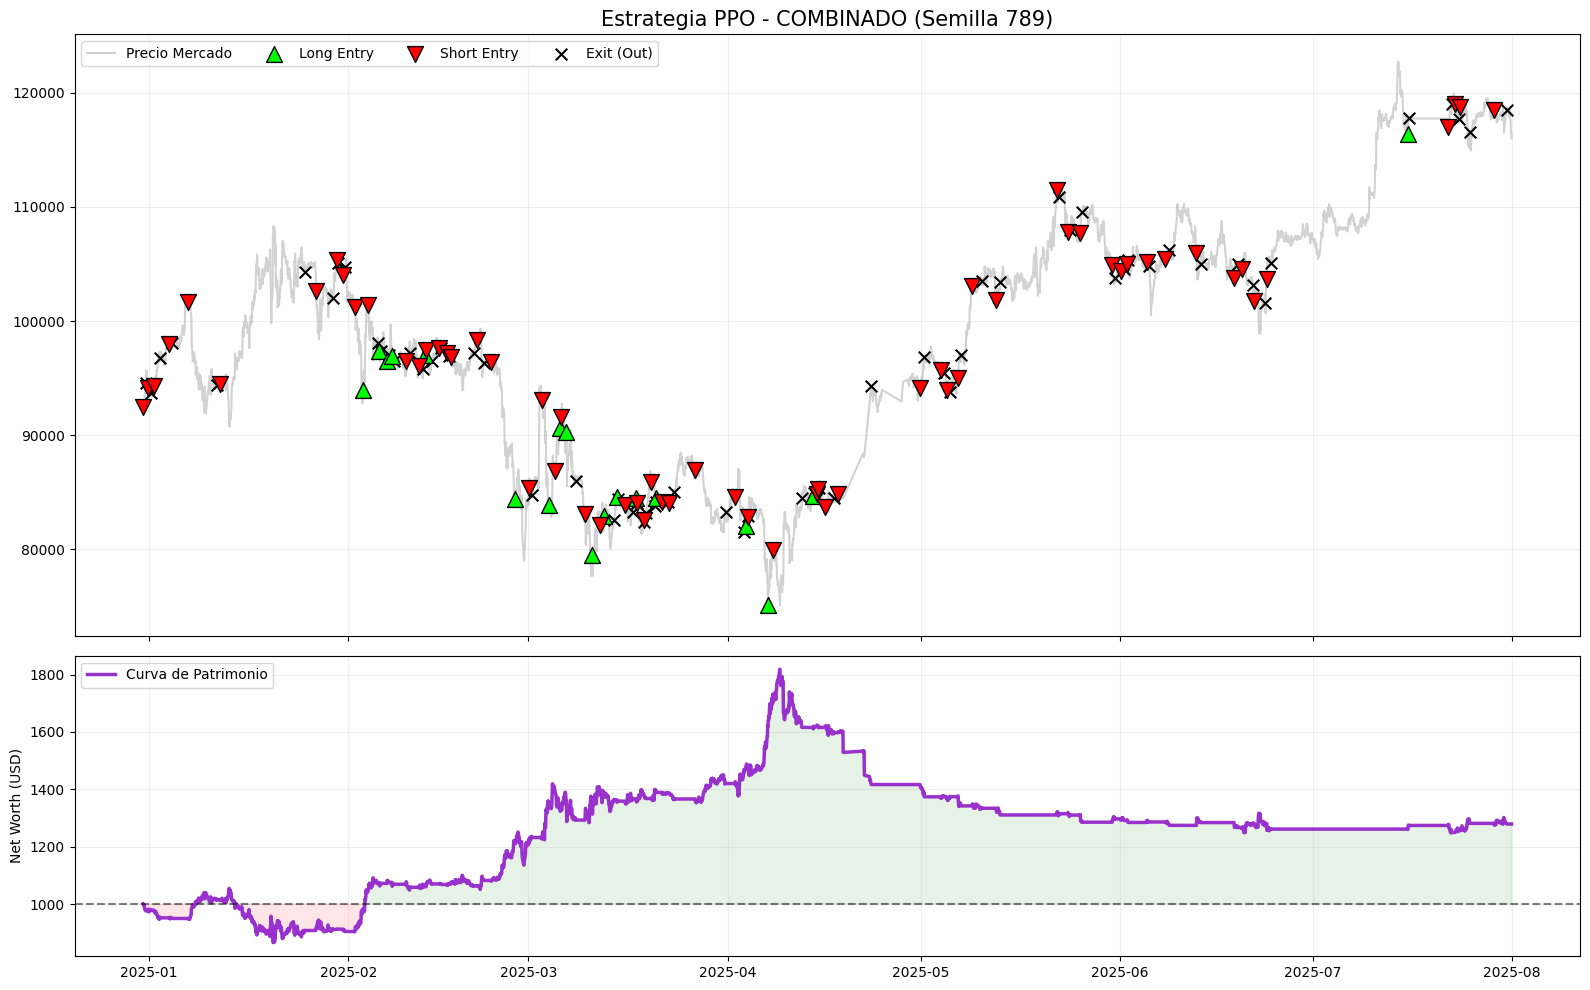


 📊 REPORTE VISUAL PPO: COMBINADO | SEED: 1011
✅ Datos PPO listos: 4698 velas para evaluación.

📈 --- RESULTADOS PPO ---
🚀 Entradas Long:   0
📉 Entradas Short:  0
✖️  Cierres (Out):   0
🔄 Operaciones totales: 0
----------------------------------
💰 Patrimonio Final: $1000.00
📊 Retorno IA:       0.00%
🌎 Retorno Mercado:  25.50%
✨ Alpha Generado:   -25.50%


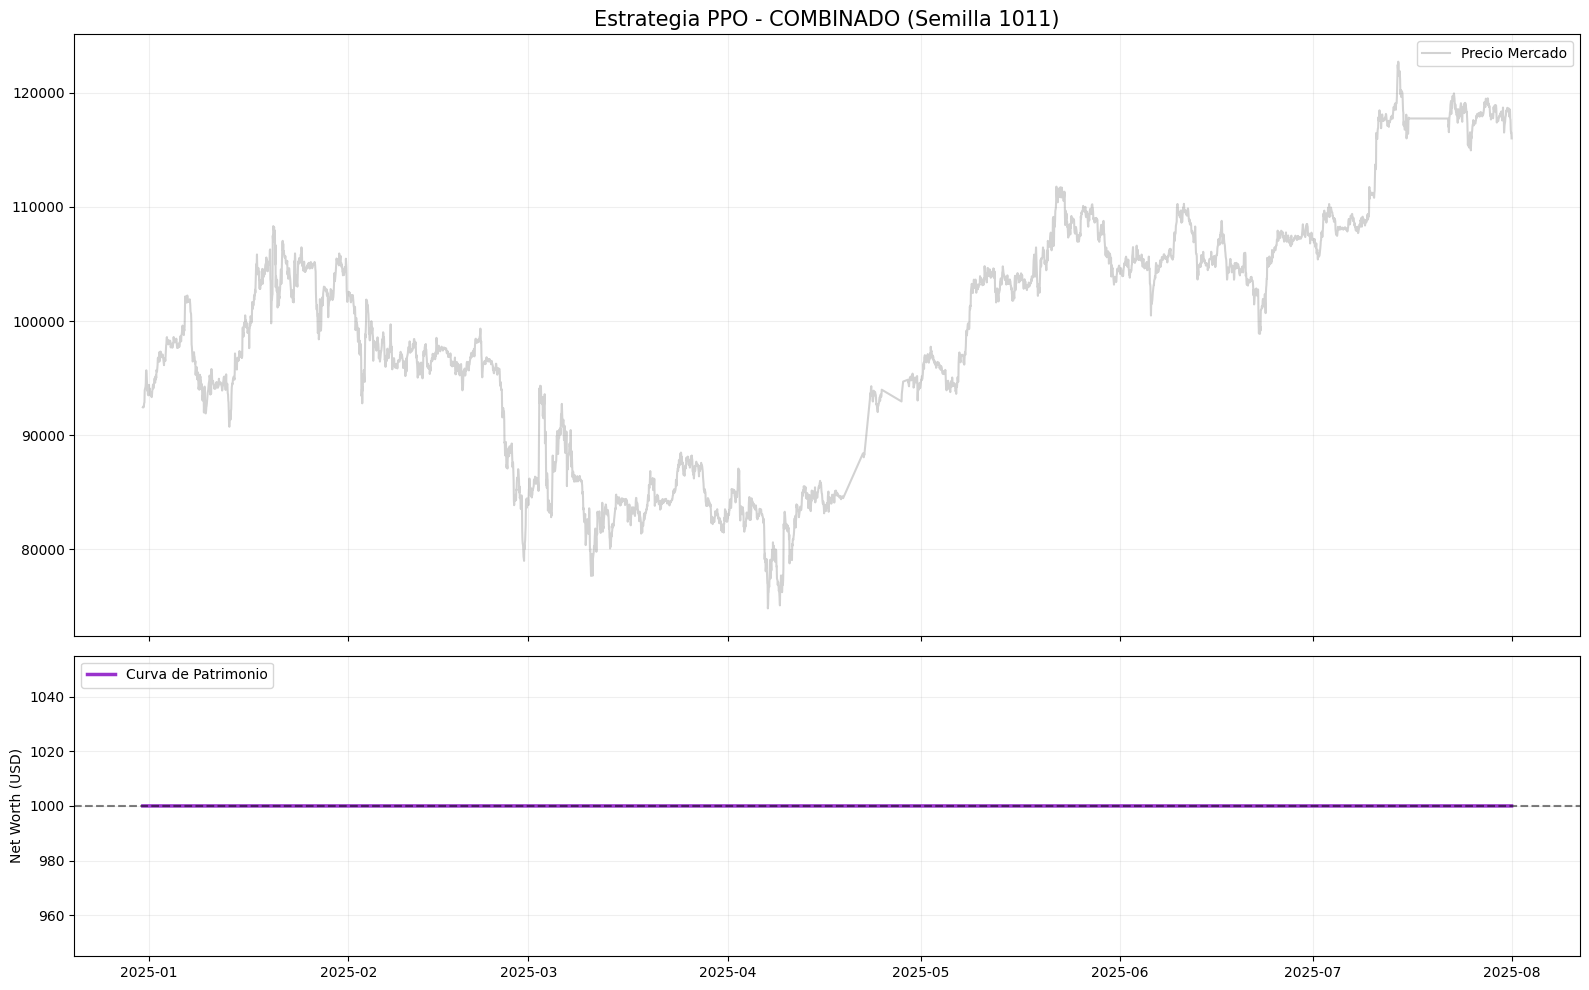

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import torch
from stable_baselines3 import PPO
from sklearn.preprocessing import MinMaxScaler

def plot_trading_results(model_name, seed, tf="1h"):
    """
    Evalúa y grafica los resultados específicos de los modelos entrenados con PPO.
    Incluye sincronización de datos, escalado y métricas de rendimiento.
    """
    print(f"\n" + "="*50)
    print(f" 📊 REPORTE VISUAL PPO: {model_name.upper()} | SEED: {seed}")
    print("="*50)

    # 1. CARGA Y PREPARACIÓN DE DATOS
    try:
        # load_data_all_types ya debe incluir el .shift(1) para el modelo 'raw'
        df_feat, df_prices = load_data_all_types(model_name, tf)
        
        # Escalado Universal (Sincronizado con el entrenamiento)
        scaler = MinMaxScaler()
        train_mask = df_feat.index <= TRAIN_END_DATE
        df_feat = df_feat.ffill().bfill().fillna(0) 
        
        # Ajuste del escalador solo con datos de entrenamiento (evitar data leakage)
        scaler.fit(df_feat.loc[train_mask])
        df_feat_scaled = pd.DataFrame(
            scaler.transform(df_feat), 
            index=df_feat.index, 
            columns=df_feat.columns
        )
        
        # Split temporal exacto
        df_feat_val = df_feat_scaled[df_feat_scaled.index > TRAIN_END_DATE]
        df_prices_val = df_prices[df_prices.index > TRAIN_END_DATE]
        
        print(f"✅ Datos PPO listos: {len(df_feat_val)} velas para evaluación.")
    except Exception as e:
        print(f"❌ Error en la preparación de datos: {e}")
        return

    # 2. CARGA DEL AGENTE PPO
    model_path = f"../RL_outputs/{foldername}/models/ppo_{model_name}_seed_{seed}.zip"
    if not os.path.exists(model_path):
        print(f"❌ No se encuentra el archivo: {model_path}")
        return
    
    agent = PPO.load(model_path)

    # 3. CONFIGURACIÓN DEL ENTORNO Y SIMULACIÓN
    init_bal = 1000
    trade_fee = 0.001 # Ajustar según tu parámetro FEE real
    
    env = SRLTradingEnv_v2(df_feat_val, df_prices_val, initial_balance=init_bal, fee=trade_fee)
    obs, _ = env.reset()
    done = False
    
    # Listas para histórico
    net_worths = []
    prices_history = []
    dates = []
    
    # Marcadores de eventos
    long_entries = []
    short_entries = []
    exits = []
    
    # Contadores operativos
    long_ops = 0
    short_ops = 0
    cierres = 0
    current_pos = 1 # 0:Short, 1:Out, 2:Long
    step = 0

    while not done:
        # Deterministic=True es vital en PPO para eliminar la aleatoriedad de la política
        action, _ = agent.predict(obs, deterministic=True)
        
        # Lógica de detección de cambios de estado
        if action != current_pos:
            if action == 2: # Entrar en Long
                long_entries.append(step)
                long_ops += 1
            elif action == 0: # Entrar en Short
                short_entries.append(step)
                short_ops += 1
            elif action == 1: # Cerrar a liquidez (Out)
                exits.append(step)
                cierres += 1
            current_pos = action
            
        obs, reward, done, _, info = env.step(action)
        
        net_worths.append(info['net_worth'])
        prices_history.append(df_prices_val.iloc[step])
        dates.append(df_prices_val.index[step])
        step += 1

    # 4. CÁLCULO DE MÉTRICAS FINALES
    final_nw = net_worths[-1]
    retorno_total = ((final_nw / init_bal) - 1) * 100
    mercado_ret = ((prices_history[-1] / prices_history[0]) - 1) * 100

    print(f"\n📈 --- RESULTADOS PPO ---")
    print(f"🚀 Entradas Long:   {long_ops}")
    print(f"📉 Entradas Short:  {short_ops}")
    print(f"✖️  Cierres (Out):   {cierres}")
    print(f"🔄 Operaciones totales: {long_ops + short_ops + cierres}")
    print("-" * 34)
    print(f"💰 Patrimonio Final: ${final_nw:.2f}")
    print(f"📊 Retorno IA:       {retorno_total:.2f}%")
    print(f"🌎 Retorno Mercado:  {mercado_ret:.2f}%")
    print(f"✨ Alpha Generado:   {retorno_total - mercado_ret:.2f}%")
    print("="*50)

    # 5. GENERACIÓN DEL GRÁFICO
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [2, 1]})
    
    # Subplot superior: Precio y Señales
    ax1.plot(dates, prices_history, color='gray', alpha=0.35, label='Precio Mercado')
    
    if long_entries:
        ax1.scatter([dates[i] for i in long_entries], [prices_history[i] for i in long_entries], 
                    marker='^', color='lime', s=130, label='Long Entry', edgecolors='black', zorder=5)
    if short_entries:
        ax1.scatter([dates[i] for i in short_entries], [prices_history[i] for i in short_entries], 
                    marker='v', color='red', s=130, label='Short Entry', edgecolors='black', zorder=5)
    if exits:
        ax1.scatter([dates[i] for i in exits], [prices_history[i] for i in exits], 
                    marker='x', color='black', s=70, label='Exit (Out)', zorder=4)
    
    ax1.set_title(f"Estrategia PPO - {model_name.upper()} (Semilla {seed})", fontsize=15)
    ax1.legend(loc='best', ncol=4)
    ax1.grid(alpha=0.2)

    # Subplot inferior: Curva de Equidad
    ax2.plot(dates, net_worths, color='darkorchid', lw=2.5, label='Curva de Patrimonio')
    ax2.axhline(y=init_bal, color='black', linestyle='--', alpha=0.5)
    
    nw_np = np.array(net_worths)
    ax2.fill_between(dates, init_bal, net_worths, where=(nw_np >= init_bal), color='green', alpha=0.1)
    ax2.fill_between(dates, init_bal, net_worths, where=(nw_np < init_bal), color='red', alpha=0.1)
    
    ax2.set_ylabel("Net Worth (USD)")
    ax2.grid(alpha=0.2)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
# Lanza los que quieras comparar:

plot_trading_results('raw', 42)


plot_trading_results('baseline', 42)
plot_trading_results('baseline', 123)
plot_trading_results('baseline', 456)
plot_trading_results('baseline', 789)
plot_trading_results('baseline', 1011)


plot_trading_results('temporal-ae', 42)
plot_trading_results('temporal-ae', 123)
plot_trading_results('temporal-ae', 456)
plot_trading_results('temporal-ae', 789)
plot_trading_results('temporal-ae', 1011)

plot_trading_results('cpc', 42)
plot_trading_results('cpc', 123)
plot_trading_results('cpc', 456)
plot_trading_results('cpc', 789)
plot_trading_results('cpc', 1011)

plot_trading_results('transformer', 42)
plot_trading_results('transformer', 123)
plot_trading_results('transformer', 456)
plot_trading_results('transformer', 789)
plot_trading_results('transformer', 1011)

plot_trading_results('combinado', 42)
plot_trading_results('combinado', 123)
plot_trading_results('combinado', 456)
plot_trading_results('combinado', 789)
plot_trading_results('combinado', 1011)

In [4]:
from stable_baselines3 import PPO

def trading_results(model_name, seed, tf="1h"):
    print(f"\n" + "="*50)
    print(f" ANALIZANDO MODELO PPO: {model_name.upper()} | SEMILLA: {seed}")
    print("="*50)

    try:
        # 1. Carga de datos (con shift(1) incluido para RAW)
        df_feat, df_prices = load_data_all_types(model_name, tf)
        
        # 2. ESCALADO UNIVERSAL (Espejo del entrenamiento)
        scaler = MinMaxScaler()
        train_mask = df_feat.index <= TRAIN_END_DATE
        df_feat = df_feat.ffill().bfill().fillna(0) 
        
        # Ajustamos solo con datos de entrenamiento
        scaler.fit(df_feat.loc[train_mask])
        
        # Transformamos TODO el dataset para el test
        df_feat_scaled = pd.DataFrame(
            scaler.transform(df_feat), 
            index=df_feat.index, 
            columns=df_feat.columns
        )
        
        # 3. SPLIT TEMPORAL
        df_feat_val = df_feat_scaled[df_feat_scaled.index > TRAIN_END_DATE]
        df_prices_val = df_prices[df_prices.index > TRAIN_END_DATE]
        
        print(f"✅ Datos PPO Escalados: {len(df_feat_val)} velas.")
        
    except Exception as e:
        print(f"❌ Error en preparación de datos PPO: {e}")
        return

    # 4. Cargar el Agente PPO
    model_path = f"../RL_outputs/{foldername}/models/ppo_{model_name}_seed_{seed}.zip"
    if not os.path.exists(model_path):
        print(f"❌ No se encuentra el archivo: {model_path}")
        return
    
    agent = PPO.load(model_path)

    # 5. Simulación
    env = SRLTradingEnv_v2(df_feat_val, df_prices_val, initial_balance=1000, fee=0.001)
    obs, _ = env.reset()
    done = False
    net_worths = []
    
    # Tracking de operaciones (3 acciones)
    total_trades = 0
    compras = 0
    ventas = 0
    current_pos = 1 # Empezamos en OUT (1)

    while not done:
        # Predecimos (Deterministic=True es clave para evaluar el modelo final)
        action, _ = agent.predict(obs, deterministic=True)
        
        if action != current_pos:
            total_trades += 1
            if action > current_pos:
                compras += 1 # Movimiento hacia Long o cerrando Short
            else:
                ventas += 1  # Movimiento hacia Short o cerrando Long
            current_pos = action
            
        obs, reward, done, _, info = env.step(action)
        net_worths.append(info.get('net_worth'))

    # 6. Resultados finales
    final_nw = net_worths[-1]
    retorno_final = ((final_nw / 1000) - 1) * 100
    
    print(f"\n--- ESTADÍSTICAS DE OPERATIVA (PPO) ---")
    print(f"🔵 Compras Totales: {compras}")
    print(f"🔴 Ventas Totales: {ventas}")
    print(f"📊 Total Cambios de Posición: {total_trades}")
    print(f"🏁 Balance Final: ${final_nw:.2f} | 📈 Retorno: {retorno_final:.2f}%")
    print("-" * 34)
    
    return retorno_final

In [5]:
# Configuración
MODELS = ['raw', 'baseline', 'temporal-ae', 'cpc', 'transformer', 'combinado']
SEEDS = [42, 123, 456, 789, 1011]

# Diccionario para guardar todo
resultados_acumulados = {m: [] for m in MODELS}

print("🚀 Iniciando recolección de resultados para el informe...")

for m in MODELS:
    for s in SEEDS:
        # Ejecutamos la función y guardamos el retorno
        ret = trading_results(m, s, tf="1h")
        if ret is not None:
            resultados_acumulados[m].append(ret)

print("\n✅ Recolección finalizada.")

🚀 Iniciando recolección de resultados para el informe...

 ANALIZANDO MODELO PPO: RAW | SEMILLA: 42
✅ Datos PPO Escalados: 535 velas.

--- ESTADÍSTICAS DE OPERATIVA (PPO) ---
🔵 Compras Totales: 1
🔴 Ventas Totales: 0
📊 Total Cambios de Posición: 1
🏁 Balance Final: $1197.00 | 📈 Retorno: 19.70%
----------------------------------

 ANALIZANDO MODELO PPO: RAW | SEMILLA: 123
✅ Datos PPO Escalados: 535 velas.

--- ESTADÍSTICAS DE OPERATIVA (PPO) ---
🔵 Compras Totales: 0
🔴 Ventas Totales: 0
📊 Total Cambios de Posición: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------

 ANALIZANDO MODELO PPO: RAW | SEMILLA: 456
✅ Datos PPO Escalados: 535 velas.

--- ESTADÍSTICAS DE OPERATIVA (PPO) ---
🔵 Compras Totales: 0
🔴 Ventas Totales: 0
📊 Total Cambios de Posición: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------

 ANALIZANDO MODELO PPO: RAW | SEMILLA: 789
✅ Datos PPO Escalados: 535 velas.

--- ESTADÍSTICAS DE OPERATIVA (PPO) ---
🔵 Compras T

In [6]:
def generar_informe_completo(data):
    rows = []
    for modelo, retornos in data.items():
        if not retornos: continue
        
        media = np.mean(retornos)
        std = np.std(retornos)
        # Usamos LaTeX para la fórmula de consistencia en la memoria
        # Consistencia = $\frac{\mu}{\sigma}$
        consistencia = media / std if std > 1e-6 else (media if media > 0 else 0)
        
        rows.append({
            "Modelo": modelo.upper(),
            "Media_Num": media,
            "Desviacion_Num": std,
            "Consistencia_Num": consistencia
        })
    
    df_base = pd.DataFrame(rows)

    def preparar_tabla(df, col_sort, ascendente=False):
        temp = df.sort_values(by=col_sort, ascending=ascendente).copy()
        temp["Media (%)"] = temp["Media_Num"].map(lambda x: f"{x:.2f}%")
        temp["Desv. Std"] = temp["Desviacion_Num"].map(lambda x: f"{x:.2f}")
        temp["Consistencia"] = temp["Consistencia_Num"].map(lambda x: f"{x:.2f}")
        return temp[["Modelo", "Media (%)", "Desv. Std", "Consistencia"]]

    # Imprimir las tablas de clasificación
    sections = [
        ("RENTABILIDAD MEDIA (¿Quién gana más?)", "Media_Num", False),
        ("ESTABILIDAD / RIESGO (¿Quién es menos volátil?)", "Desviacion_Num", True),
        ("CONSISTENCIA (Ratio Media/Riesgo)", "Consistencia_Num", False)
    ]

    for titulo, col, asc in sections:
        print("\n" + "="*70)
        print(titulo)
        print("="*70)
        print(preparar_tabla(df_base, col, asc).to_string(index=False))

# ¡Y finalmente ejecutamos!
generar_informe_completo(resultados_acumulados)


RENTABILIDAD MEDIA (¿Quién gana más?)
     Modelo Media (%) Desv. Std Consistencia
   BASELINE    10.12%      8.83         1.15
TRANSFORMER     5.57%      7.71         0.72
        RAW     3.90%     14.81         0.26
        CPC     3.50%      8.14         0.43
TEMPORAL-AE    -2.00%     13.44        -0.15
  COMBINADO    -4.30%      4.03        -1.07

ESTABILIDAD / RIESGO (¿Quién es menos volátil?)
     Modelo Media (%) Desv. Std Consistencia
  COMBINADO    -4.30%      4.03        -1.07
TRANSFORMER     5.57%      7.71         0.72
        CPC     3.50%      8.14         0.43
   BASELINE    10.12%      8.83         1.15
TEMPORAL-AE    -2.00%     13.44        -0.15
        RAW     3.90%     14.81         0.26

CONSISTENCIA (Ratio Media/Riesgo)
     Modelo Media (%) Desv. Std Consistencia
   BASELINE    10.12%      8.83         1.15
TRANSFORMER     5.57%      7.71         0.72
        CPC     3.50%      8.14         0.43
        RAW     3.90%     14.81         0.26
TEMPORAL-AE    -2.00% 

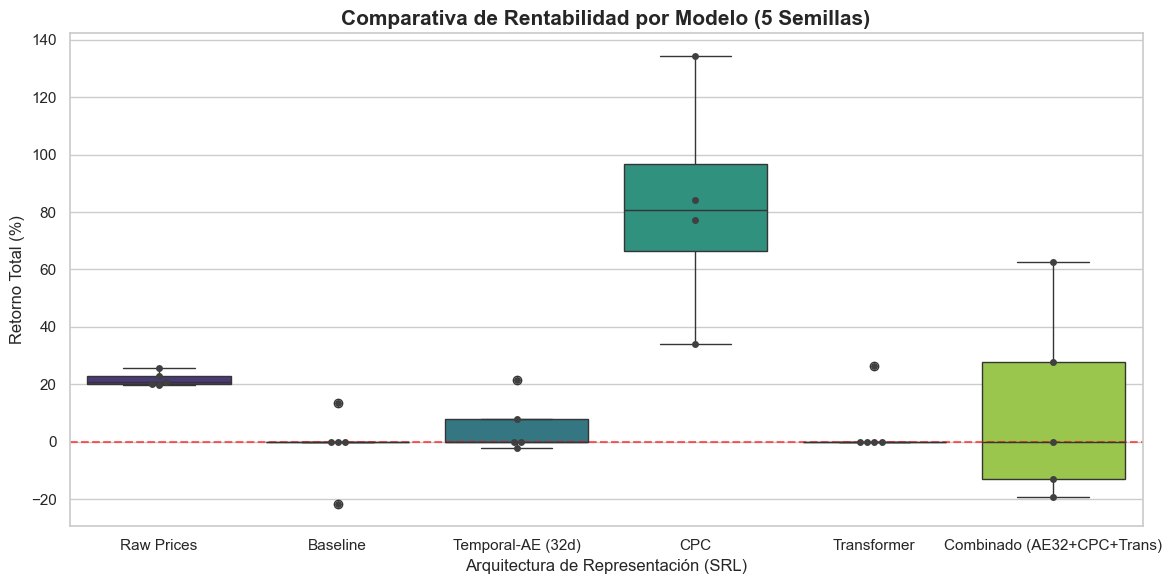

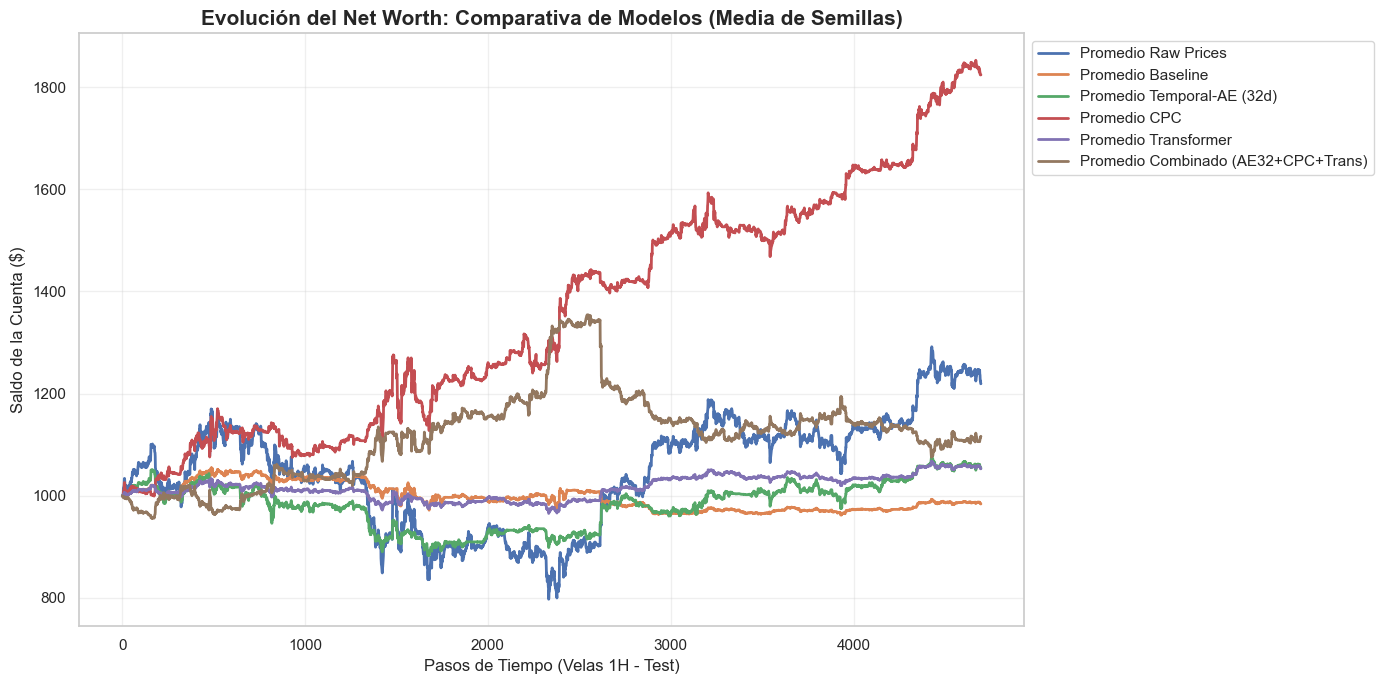

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def graficar_comparativa_tfg(batch_results):
    # 1. Preparar datos para el Boxplot
    df_results = pd.DataFrame(batch_results)
    # Convertir nombres a algo más bonito para el gráfico
    name_map = {
        'raw': 'Raw Prices',
        'baseline': 'Baseline',
        'temporal-ae': 'Temporal-AE (32d)',
        'cpc': 'CPC',
        'transformer': 'Transformer',
        'combinado': 'Combinado (AE32+CPC+Trans)'
    }
    df_results['srl_model'] = df_results['srl_model'].map(name_map)
    df_results['return_pct'] = df_results['total_return'] * 100

    # Configuración de estilo
    sns.set_theme(style="whitegrid")
    plt.rcParams['figure.dpi'] = 100

    # --- GRÁFICA 1: BOXPLOT (Estabilidad y Retorno) ---
    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(x='srl_model', y='return_pct', data=df_results, 
                     palette="viridis", hue='srl_model', legend=False)
    sns.swarmplot(x='srl_model', y='return_pct', data=df_results, color=".25", size=5)
    
    plt.title('Comparativa de Rentabilidad por Modelo (5 Semillas)', fontsize=15, fontweight='bold')
    plt.ylabel('Retorno Total (%)', fontsize=12)
    plt.xlabel('Arquitectura de Representación (SRL)', fontsize=12)
    plt.axhline(0, color='red', linestyle='--', alpha=0.6) # Línea de 0 beneficio
    plt.tight_layout()
    plt.show()

    # --- GRÁFICA 2: EQUITY CURVES (Evolución del dinero) ---
    # Vamos a graficar la curva promedio de cada modelo para que no sea un caos de líneas
    plt.figure(figsize=(14, 7))
    
    for model in df_results['srl_model'].unique():
        # Filtramos por modelo
        model_data = df_results[df_results['srl_model'] == model]
        # Sacamos todas las curvas de equity (net worth)
        curves = np.array(model_data['equity_curve'].tolist())
        # Calculamos la media de las 5 semillas
        mean_curve = curves.mean(axis=0)
        
        plt.plot(mean_curve, label=f'Promedio {model}', linewidth=2)

    plt.title('Evolución del Net Worth: Comparativa de Modelos (Media de Semillas)', fontsize=15, fontweight='bold')
    plt.xlabel('Pasos de Tiempo (Velas 1H - Test)', fontsize=12)
    plt.ylabel('Saldo de la Cuenta ($)', fontsize=12)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Ejecutar:
graficar_comparativa_tfg(batch_results)

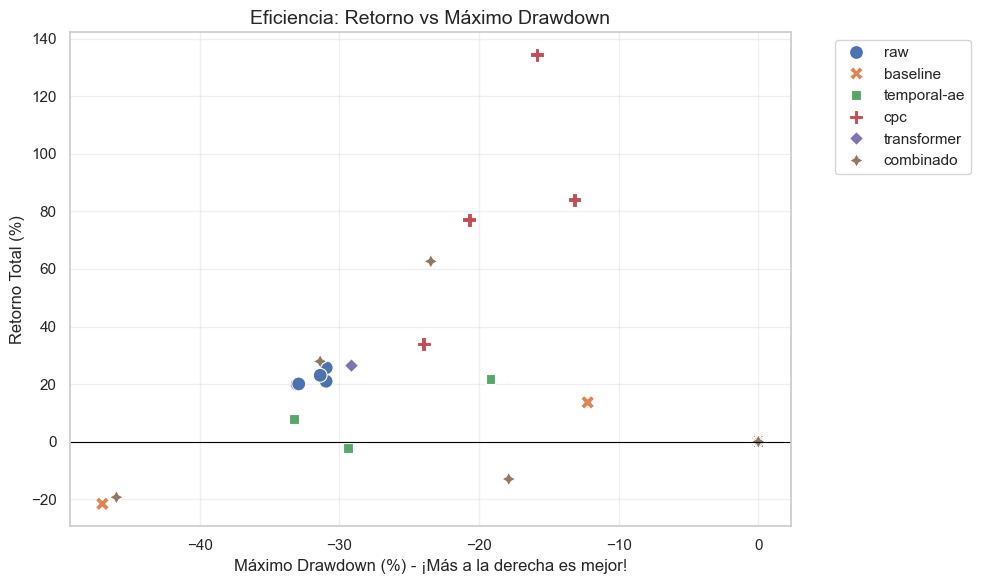


📊 RESUMEN DE RIESGO-RECOMPENSA:
            return_pct        max_drawdown       
                  mean    std         mean    min
srl_model                                        
baseline         -1.59  12.65       -11.84 -46.96
combinado        11.64  33.79       -23.73 -45.96
cpc              82.38  41.20       -18.41 -23.96
raw              21.93   2.44       -31.83 -33.02
temporal-ae       5.45   9.84       -16.36 -33.26
transformer       5.28  11.81        -5.83 -29.13


In [13]:
def calcular_metricas_financieras(batch_results):
    df = pd.DataFrame(batch_results)
    
    # 1. Función para calcular Max Drawdown
    def get_max_drawdown(equity_curve):
        equity_curve = np.array(equity_curve)
        peak = np.maximum.accumulate(equity_curve)
        drawdown = (equity_curve - peak) / peak
        return drawdown.min() * 100

    df['max_drawdown'] = df['equity_curve'].apply(get_max_drawdown)
    df['return_pct'] = df['total_return'] * 100

    # --- GRÁFICA: RETORNO VS RIESGO (SCATTER PLOT) ---
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='max_drawdown', y='return_pct', hue='srl_model', style='srl_model', s=100)
    
    plt.title('Eficiencia: Retorno vs Máximo Drawdown', fontsize=14)
    plt.xlabel('Máximo Drawdown (%) - ¡Más a la derecha es mejor!', fontsize=12)
    plt.ylabel('Retorno Total (%)', fontsize=12)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # --- TABLA RESUMEN PARA TU MEMORIA ---
    resumen = df.groupby('srl_model').agg({
        'return_pct': ['mean', 'std'],
        'max_drawdown': ['mean', 'min']
    }).round(2)
    
    print("\n📊 RESUMEN DE RIESGO-RECOMPENSA:")
    print(resumen)
    return resumen

# Ejecutar
resumen_tfg = calcular_metricas_financieras(batch_results)